# Линейная регрессия. Часть 1

Корреляция показывает степень совместного изменения двух признаков. При этом,
как уже было сказано, в корреляционном анализе нет зависимых и независимых
переменных. Они эквивалентны.

Количественным предсказанием одной переменной (зависимой) на основании
другой (независимой) занимается регрессионный анализ.

## Регрессионный анализ
Вначале немного теории.
### Генеральная совокупность и выборка
Как мы уже знаем, множество всех имеющихся наблюдений принято называть
генеральной совокупностью (population). И эти наблюдения, если в них есть
взаимосвязи, можно теоретически аппроксимировать, например, линией регрессии.
При этом важно понимать, что это некоторая идеальная модель, которую мы
никогда не сможем построить.

Единственное, что мы можем сделать, взять выборку (sample) и на ней построить
нашу модель, предполагая, что если выборка достаточно велика, она сможет
достоверно описать генсовокупность.

![](https://drive.google.com/uc?export=view&id=1YwwZktr9IiXB5T69aLWbybtDp0Tm3GBI)

Отклонение прогнозного значения от фактического для «идеальной» линии принято
называть **ошибкой** (error или true error).
$$ \varepsilon = y-\hat{y} $$
Отклонение прогноза от факта для выборочной модели (которую мы и строим)
называют **остатками** (residuals или residual error).
$$ \varepsilon = y-f(x) $$

В этом смысле среднеквадратическую ошибку (mean squared error, MSE)
корректнее называть средними квадратичными остатками (mean squared
residuals).

На практике ошибку и остатки нередко используют как взаимозаменяемые термины.

### Уравнение множественной линейной регрессии
Посмотрим на уравнение множественной линейной регрессии.
$$ y = \theta_0 + \theta_1x_1 + \theta_2x_2 +… + \theta_jx_j + \varepsilon $$
В отличие от простой линейной регрессии в данном случае у нас несколько
признаков $x_j$ (независимых переменных) и несколько коэффициентов $ \theta_j.$
### Интерпретация результатов модели
**Коэффициент $ \theta_0 $** задает некоторый базовый уровень (baseline) при
условии, что остальные коэффициенты равны нулю и зачастую не имеет смысла с
точки зрения интерпретации модели (нужен лишь для того, чтобы сдвинуть линию
регрессии на нужный уровень).

**Параметры $ \theta_1, \theta_2, …, \theta_d $** показывают изменение зависимой
переменной при условии «неподвижности» остальных коэффициентов. Например,
каждая дополнительная комната может увеличивать цену дома в 1,3 раза.

**Переменная $ \varepsilon $** (ошибка) представляет собой отклонение
фактических данных от прогнозных. В этой переменной могут быть заложены две
составляющие:
* во-первых, она может включать вариативность целевой переменной,
описанную другими (не включенными в нашу модель) признаками;
* во-вторых, «улавливать» случайный шум, случайные колебания.

### Категориальные признаки
Модель линейной регрессии может включать категориальные признаки. Продолжая
пример с квартирой, предположим, что мы строим модель, в которой цена зависит
от того, находится ли квартира в центре города или в спальном районе.
Перед этим переменную необходимо закодировать, создав, например, через
Label Encoder признак «центр», который примет значение 1, если квартира в
центре, и 0, если она находится в спальном районе.

![](https://drive.google.com/uc?export=view&id=1Hb_m1ddurcHm0ipdxiAounJkHXyWnfjG)

В модели, представленной выше, если квартира находится в центре (переменная
«центр» равна единице), ее стоимость составит 10,1 миллиона рублей, если на
окраине (переменная «центр» равна нулю) — лишь восемь.
Для категориального признака с множеством классов можно использовать one-hot
encoding, если между классами признака отсутствует иерархия
![](https://drive.google.com/uc?export=view&id=1llnJi7T8u4JGv7tYeGwZrYN29BDwtPQa)

или, например, ordinal encoding в случае наличия иерархии классов в признаке

![](https://drive.google.com/uc?export=view&id=16jviSt3xblXKDjsNV0q5qgobcj2c3DC-)

### Выбросы в линейной регрессии

Как и коэффициент корреляции Пирсона, модель линейной регрессии
чувствительна к **выбросам** (outliers), то есть наблюдениям, заметно
отличающимся от общей совокупности. Сравните рисунки ниже.

![](https://drive.google.com/uc?export=view&id=1zbeOGq-Ao83JGdAupCGhdTUi0mH1jVfG)

При наличии выброса (слева), линия регрессии имеет наклон и может
использоваться для построения прогноза. Удалив это наблюдение (справа), линия
регрессии становится горизонтальной и построение прогноза теряет смысл.

При этом различают два типа выбросов:
* горизонтальные выбросы или влиятельные точки (leverage points) — они
сильно отклоняются от среднего по оси x; и
* вертикальные выбросы или просто выбросы (influential points) —
отклоняются от среднего по оси y.

Ключевое отличие заключается в том, что вертикальные выбросы влияют на
наклон модели (изменяют ее коэффициенты), а горизонтальные — нет.

Сравним два графика.

![](https://drive.google.com/uc?export=view&id=1cpe4pcHkIVbm7fLbgVDXtzIcAU_QL0Av)

На левом графике черная точка (leverage point) сильно отличается от остальных
наблюдений, но наклон прямой линии регрессии с ее появлением не изменился. На
правом графике, напротив, появление выброса (influential point) существенно
изменяет наклон прямой.

На практике нас конечно больше интересуют influential points, потому что
именно они существенно влияют на качество модели.

Если в простой линейной регрессии мы можем оценить leverage и influence
наблюдения графически⧉, в многомерной модели это сделать сложнее. Можно
использовать график остатков (об этом ниже) или применить один из уже
известных нам методов выявления выбросов.

Про выявление leverage и infuential points можно почитать здесь (https://online.stat.psu.edu/stat462/node/87/).


## Допущения модели регрессии
Применение алгоритма линейной регрессии предполагает несколько допущений
(assumptions) или условий, при выполнении которых мы можем говорить о качественно построенной модели.
### 1. Правильный выбор модели
Вначале важно убедиться, что данные можно аппроксимировать с помощью
линейной модели (correct model specification).

Оценить распределение данных можно через **график остатков** (residuals plot), где
по оси x отложен прогноз модели, а на оси y — сами остатки.

![](https://drive.google.com/uc?export=view&id=1z-46Pz-P4ZWrqv1KBfqIJVfvwVf1zPH1)

В отличие от простой линейной регрессии мы не используем точечную
диаграмму X vs. y, потому что хотим оценить зависимость целевой
переменной от всех признаков сразу.

Остатки модели относительно ее прогнозных значений должны быть распределены
случайным образом без систематической составляющей. При этом,
* если вы попробовали применить линейную модель с коэффициентами первой
степени $x_d^1$ и выявили некоторый паттерн в данных, можно попробовать
полиномиальную или какую-либо еще функцию (об этом будет сказано далее);
кроме того,
* количественные признаки можно попробовать преобразовать таким образом,
чтобы их можно было аппроксимировать прямой линией;
* если ни то, ни другое не помогло, вероятно данные не стоит моделировать
линейной регрессией.

Также замечу, что график остатков показывает выбросы в данных.

![](https://drive.google.com/uc?export=view&id=1_Kdodzp3i-hsF9tSQE-ZfaXx4WLTkoW1)

### 2. Нормальность распределения остатков
Среднее значение остатков должно быть равно нулю. Если это не так, и среднее
значение *меньше нуля* (скажем $-5$), то это значит, что модель регулярно
недооценивает (underestimates) фактические значения. В противном случае, если
среднее *больше нуля*, переоценивает (overestimated).

![](https://drive.google.com/uc?export=view&id=1OM52Nx-KMG6T9wehMFoLe-USoPXI0Jhd)

Кроме того, предполагается, что остатки следуют нормальному распределению.

$$ \varepsilon \sim N(0, \sigma) $$

Проверить нормальность остатков можно визуально с помощью гистограммы
или рассмотренных ранее критериев нормальности распределения.

Причинами могут быть (1) выбросы в данных или (2) неверный выбор модели.
Решением может быть, соответственно, исследование выбросов, выбор новой
модели и преобразование как признаков, так и целевой переменной.


### 3. Гомоскедастичность остатков
**Гомоскедастичность** (homoscedasticity) или одинаковая изменчивость остатков
предполагают, что дисперсия остатков не изменяется для различных наблюдений.
Противоположное и нежелательное явление называется
**гетероскедастичностью** (heteroscedasticity) или разной изменчивостью.
![](https://drive.google.com/uc?export=view&id=13WDfGylSsOKDyct2vUwU4G0w9A5NblF9)

Гетероскедастичность остатков показывает, что модель ошибается сильнее при
более высоких или более низких значениях признаков. Как следствие, если для
разных прогнозов у нас разная погрешность, модель нельзя назвать надежной
(robust).

Как правило, гетероскедастичность бывает изначально заложена в данные. Ее
можно попробовать исправить через преобразование целевой переменной
(например, логарифмирование).
### 4. Отсутствие мультиколлинеарности
Еще одним важным допущением является отсутствие мультиколлинеарности.
**Мультиколлинеарность** (multicollinearity) — это корреляция между
независимыми переменными. Например, если мы предсказываем стоимость жилья
по квадратным метрам и количеству комнат, то метры и комнаты логичным
образом также будут коррелировать между собой.

Почему плохо, если такая корреляция существует? Базовое предположение
линейной регрессии — каждый коэффициент $\theta$ оказывает влияние на
конечный результат при условии, что остальные коэффициенты постоянны. При
мультиколлинеарности на целевую переменную оказывают эффект сразу несколько признаков, а значит мы не можем с точностью интерпретировать каждый из них.

Также говорят о том, что нужно стремиться к **экономной** (parsimonious)
модели, то есть такой модели, которая при наименьшем количестве признаков
в наибольшей степени объясняет поведение целевой переменной.

#### Variance inflation factor
#### Расчет коэффициента
**Variance inflation factor** (VIF) или коэффициент увеличения дисперсии позволяет
выявить корреляцию между признаками модели.

Принцип расчета VIF заключается в том, чтобы поочередно делать каждый из
признаков целевой переменной и строить модель линейной регрессии на основе
оставшихся независимых переменных. Например, если у нас есть три признака
$x_1, x_2, x_3$, мы поочередно построим три модели линейной регрессии: $x_1
\sim x_2 + x_3, x_2 \sim x_1 + x_3$ и $x_3 \sim x_1 + x_3$.

Обратите внимание на новый для нас формат записи целевой и зависимых
переменных модели через символ $\sim.$

Затем для каждой модели (то есть для каждого признака $x_1, x_2, x_3$) мы
рассчитаем коэффициент детерминации $R^2.$ Если он велик, значит данный
признак можно объяснить с помощью других независимых переменных и имеется
мультиколлинеарность. Если $R^2$ мал, то нельзя и мультиколлинеарность
отсутствует.

Теперь рассчитаем VIF на основе $R^2$:

$$ VIF = \frac{1}{1-R^2} $$

При таком способе расчета большой (близкий к единице) $R^2$ уменьшит
знаменатель и существенно увеличит VIF, при небольшом коэффициенте детерминации коэффициент увеличения дисперсии наоборот уменьшится.

Замечу, что $1-R^2$ принято называть tolerance.
#### Другие способы выявления мультиколлинеарности
Для выявления корреляции между независимыми переменными можно
использовать точечные диаграммы или корреляционные матрицы. При этом важно
понимать, что в данном случае мы выявляем зависимость лишь между двумя
признаками. Корреляцию множества признаков выявляет только коэффициент
увеличения дисперсии.
#### Интерпретация VIF
VIF находится в диапазоне от единицы до плюс бесконечности. Как правило, при
интерпретации показателей variance inflation factor придерживаются следующих
принципов:
* $\text{VIF} = 1$, между признаками отсутствует корреляция;
* $1 < \text{VIF} \leq 5$ — умеренная корреляция;
* $5 < \text{VIF} \leq 10$ — высокая корреляция;
* более $10$ — очень высокая.

После расчета VIF можно по одному удалять признаки с наибольшей корреляцией
и смотреть, как изменится этот показатель для оставшихся независимых
переменных.

### 5. Отсутствие автокорреляции остатков
На занятии по временным рядам (time series), мы сказали, что автокорреляция
(autocorrelation) — это корреляция между значениями одной и той же переменной в
разные моменты времени.

Применительно к модели линейной регрессии автокорреляция целевой переменной
(для простой линейной регрессии) и автокорреляция остатков, residuals
autocorrelation (для модели множественной регрессии) означает, что результат или
прогноз зависят не от признаков, а от самой целевой переменной. В такой ситуации
признаки теряют свою значимость, и применение модели регрессии становится
нецелесообразным.
#### Причины автокорреляции остатков
Приведем две возможные причины:
* прогнозирование целевой переменной с высокой автокорреляцией (например,
если мы моделируем цену акций с помощью других переменных, то можем
ожидать высокую автокорреляцию остатков, поскольку цена акций как
правило сильно зависит от времени);
* удаление значимых признаков.

#### Автокорреляция первого порядка
Дадим формальное определение автокорреляции первого порядка (first order
correlation), то есть автокорреляции с лагом 1.
$$ \varepsilon_t = p\varepsilon_{t-1} + u_t, \quad \text{где} $$

* $u_t$ — некоррелированная при различных $t$ одинаково распределенная
случайная величина (independent and identically distributed (i.i.d.) random
variable); а
* $p$ — коэффициент автокорреляции, который находится в диапазоне $-1 < p <
1$.

Чем он ближе к нулю, тем меньше зависимость остатка $\varepsilon_t$ от остатка
предыдущего периода $\varepsilon_{t-1}.$

Такое уравнение также называется **схемой Маркова** первого порядка
(Markov first-order scheme).

Обратите внимание, что для модели автокорреляции первого порядка коэффициент
автокорреляции $p$ совпадает с коэффициентом авторегрессии AR(1) $\varphi.$

$$ y_t = c + \varphi \cdot y_{t-1} $$

Разумеется, мы можем построить модель автокорреляции, например, третьего
порядка.

$$ \varepsilon_t = p_1\varepsilon_{t-1} + p_2\varepsilon_{t-2} + p_3\varepsilon_{t-3} +
u_t $$

#### Выявление автокорреляции остатков
Для выявления автокорреляции остатков можно использовать график
последовательности и график остатков с лагом 1, график автокорреляционной
функции или критерий Дарбина-Уотсона.

График последовательности и график остатков с лагом 1

На **графике последовательности** (sequence plot) по оси x откладывается время
(или порядковый номер наблюдения), а по оси y — остатки модели. Кроме того, на
**графике остатков** с лагом 1 (lag-1 plot) остатки (ось y) можно сравнить с этими
же значениями, взятыми с лагом 1 (ось x).

Рассмотрим вариант **положительной автокорреляции** (positive autocorrelation).

![](https://drive.google.com/uc?export=view&id=1LQMPb3AJ29fxwOk2VKgUqNhxYLwsv8BP)

Как вы видите, при положительной автокорреляции в большинстве случаев, если
одно наблюдение демонстрирует рост по отношению к предыдущему значению, то
и последующее будет демонстрировать рост, и наоборот.

Теперь обратимся к отрицательной автокорреляции (negative autocorrelation).

![](https://drive.google.com/uc?export=view&id=1XGvv4yI4ccH97tJHHRKr7MKilPsQ5KCq)

Здесь наоборот, если одно наблюдение демонстрирует рост показателя по отношению к предыдущему значению, то последующее наблюдение будет
наоборот снижением. Опять же справедливо и обратное утверждение.

В случае **отсутствия автокорреляции** мы не должны увидеть на графиках какого-либо паттерна.

![](https://drive.google.com/uc?export=view&id=1en6iqiBDbEkVklCcnr37EOy-nJ4PV1hY)

График автокорреляционной функции

Еще один способ выявить автокорреляцию — построить график
автокорреляционной функции **Текст, выделенный полужирным шрифтом** (autocorrelation function, ACF).

![](https://drive.google.com/uc?export=view&id=18lUzFYTQWWHmGvQ8Oljha011HcuYcmY5)

*Занятие по временным рядам (данные о рождаемости)*

Напомню, такой график показывает автокорреляцию данных с этими же данными, взятыми с первым, вторым и последующими лагами.
#### Критерий Дарбина-Уотсона
Количественным выражением автокорреляции является критерий
Дарбина-Уотсона **Текст, выделенный полужирным шрифтом** (Durbin-Watson test). Этот критерий выявляет только
автокорреляцию первого порядка:
* **нулевая гипотеза** утверждает, что такая автокорреляция отсутствует,
$p=0;$
* **альтернативная гипотеза** соответственно утверждает, что присутствует:
  * положительная, $p \approx -1;$ или
  * отрицательная, $p \approx 1,$ автокорреляция.

Значение теста находится в диапазоне от 0 до 4. При этом,
* при показателе близком к двум можно говорить об отсутствии
автокорреляции;
* приближение к четырем говорит о положительной автокорреляции;
* к нулю, об отрицательной.

#### Как избавиться от автокорреляции

Автокорреляцию можно преодолеть, добавив значимый признак в модель, выбрав
иной тип модели (например, полиномиальную регрессию) или в целом перейдя к
моделированию и прогнозированию временного ряда.

Рассмотрение этих методов находится за рамками сегодняшнего занятия.

# Линейная регрессия. Часть 2
Перейдем к практике.
## Сквозной пример
### Данные и постановка задачи
Обратимся к хорошо знакомому нам датасету недвижимости в Бостоне.


# Множественная линейная регрессия

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
boston = pd.read_csv('/content/boston.csv')

При этом нам нужно будет решить две основные задачи:

**Задача 1.** Научиться оценивать качество модели не только с точки зрения метрики качества, но и исходя из рассмотренных ранее допущений модели. Эту задачу мы
решим в три этапа.
* **Этап 1.** Построим базовую (baseline) модель линейной регрессии с помощью
класса LinearRegression библиотеки sklearn и оценим, насколько выполняются
рассмотренные выше допущения.
* **Этап 2.** Попробуем изменить данные таким образом, чтобы модель в
большей степени соответствовала этим критериям.
* **Этап 3.** Обучим еще одну модель и посмотрим, как изменится результат.

**Задача 2.** С нуля построить модель множественной линейной регрессии и
сравнить прогноз с результатом, полученным при решении первой задачи. При этом
обучение модели мы реализуем двумя способами, а именно, через:
* метод наименьших квадратов; и
* метод градиентного спуска.
#### Разделение выборки
Мы уже не раз говорили про важность разделения выборки на обучающую и
тестовую части. Сегодня же, с учетом того, что нам предстоит изучить много
нового материала, мы опустим этот этап и будем обучать и тестировать модель на
одних и тех же данных.


### EDA Исследовательский анализ данных
Теперь давайте более внимательно посмотрим на имеющиеся у нас данные. Как вы
вероятно заметили, все признаки в этом датасете количественные, за исключением
переменной CHAS.

In [ ]:
boston.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 14 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   CRIM     506 non-null    float64
 1   ZN       506 non-null    float64
 2   INDUS    506 non-null    float64
 3   CHAS     506 non-null    float64
 4   NOX      506 non-null    float64
 5   RM       506 non-null    float64
 6   AGE      506 non-null    float64
 7   DIS      506 non-null    float64
 8   RAD      506 non-null    float64
 9   TAX      506 non-null    float64
 10  PTRATIO  506 non-null    float64
 11  B        506 non-null    float64
 12  LSTAT    506 non-null    float64
 13  MEDV     506 non-null    float64
dtypes: float64(14)
memory usage: 55.5 KB


In [ ]:
# мы видим, что переменная CHAS категориальная
boston.CHAS.value_counts()

,count
CHAS,
0.0,471
1.0,35


Посмотрим на распределение признаков с помощью boxplots.

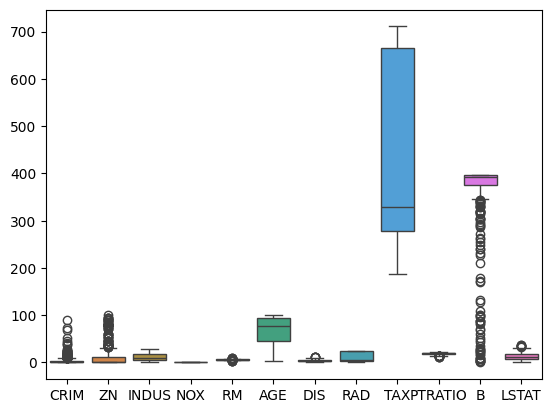

In [ ]:
sns.boxplot(data = boston.drop(columns = ['CHAS', 'MEDV']));

Посмотрим на распределение целевой переменной.

In [ ]:
def box_density(x):
  # создадим два подграфика
  f, (ax_box, ax_kde) = plt.subplots(nrows = 2, # из двух строк
                                      ncols = 1, # и одного столбца
                                      sharex = True, # оставим только нижние подписи к оси x
                                      gridspec_kw = {'height_ratios': (.15, .85)}) # зададим разную высоту строк

  # в первом подграфике построим boxplot
  sns.boxplot(x = x, ax = ax_box)
  ax_box.set(xlabel = None)
  # во втором - график плотности распределения
  sns.kdeplot(x, fill = True)

  # зададим заголовок и подписи к осям
  ax_box.set_title('Распределение переменной', fontsize = 15)
  ax_kde.set_xlabel('Переменная', fontsize = 13)
  ax_kde.set_ylabel('Плотность распределения', fontsize = 13)

  plt.show()

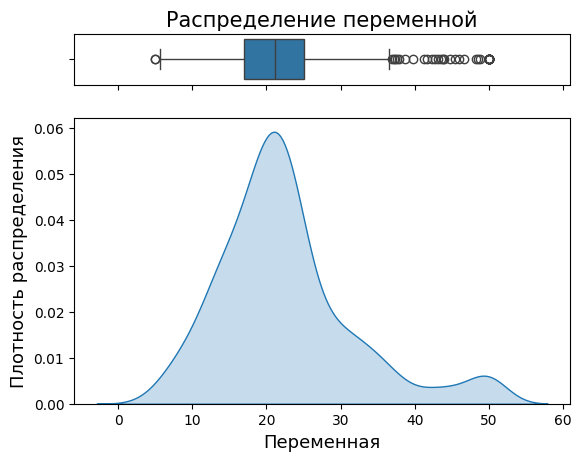

In [ ]:
box_density(boston.iloc[:, -1])

Посмотрим на корреляцию количественных признаков с целевой переменной.

In [ ]:
boston.drop(columns = 'CHAS').corr().MEDV.to_frame().style.background_gradient()

,MEDV
CRIM,-0.388305
ZN,0.360445
INDUS,-0.483725
NOX,-0.427321
RM,0.695360
AGE,-0.376955
DIS,0.249929
RAD,-0.381626
TAX,-0.468536
PTRATIO,-0.507787


Используем точечно-бисериальную корреляцию для оценки взамосвязи переменной
CHAS и целевой переменной.

In [ ]:
def pbc(continuous, binary):

  # преобразуем количественную переменную в массив Numpy
  continuous_values = np.array(continuous)
  # классы качественной переменной превратим в нули и единицы
  binary_values = np.unique(binary, return_inverse = True)[1]

  # создадим две подгруппы количественных наблюдений
  # в зависимости от класса дихотомической переменной
  group0 = continuous_values[np.argwhere(binary_values == 0).flatten()]
  group1 = continuous_values[np.argwhere(binary_values == 1).flatten()]

  # найдем средние групп,
  mean0, mean1 = np.mean(group0), np.mean(group1)
  # а также длины групп и всего датасета
  n0, n1, n = len(group0), len(group1), len(continuous_values)

  # рассчитаем СКО количественной переменной
  std = continuous_values.std()

  # подставим значения в формулу
  return (mean1 - mean0) / std * np.sqrt( (n1 * n0) / (n * (n-1)) )

In [ ]:
pbc(boston.MEDV, boston.CHAS)

np.float64(0.17543361629972762)

### Обработка данных

#### Пропущенные значения
Посмотрим, есть ли пропущенные значения.

In [ ]:
boston.isnull().sum()

,0
CRIM,0
ZN,0
INDUS,0
CHAS,0
NOX,0
RM,0
AGE,0
DIS,0
RAD,0
TAX,0


#### Выбросы
Удалим выбросы.

In [ ]:
from sklearn.ensemble import IsolationForest

clf = IsolationForest(max_samples = 100, random_state = 42)
clf.fit(boston)

boston['anomaly'] = clf.predict(boston)
boston = boston[boston.anomaly == 1]
boston = boston.drop(columns = 'anomaly')
boston.shape

(402, 14)

При удалении выбросов важно помнить, что полное отсутствие вариантивности в
данных не позволит выявить взаимосвязи.

#### Масштабирование признаков
Приведем признаки к одному масштабу (целевую переменную трогать не будем).

In [ ]:
boston.iloc[:, :-1] = (boston.iloc[:, :-1] - boston.iloc[:, :-1].mean()) / boston.iloc[:, :-1].std()

Замечу, что метод наименьших квадратов не требует масштабирования признаков,
градиентному спуску же напротив необходимо, чтобы все значения находились в
одном диапазоне (подробнее "Линейная регрессия. Часть 3").

#### Кодирование категориальных переменных
После стандартизации переменная CHAS также сохранила только два значения.

In [ ]:
boston.CHAS.value_counts()

,count
CHAS,
-0.182581,389
5.463391,13


Ее можно не трогать.

## Построение модели регрессии

Создадим первую пробную (baseline) модель с помощью библиотеки sklearn.

### baseline-модель

In [ ]:
X = boston.drop('MEDV', axis = 1)
y = boston['MEDV']

from sklearn.linear_model import LinearRegression

model = LinearRegression()
y_pred = model.fit(X, y).predict(X)

### Оценка качества
#### иагностика модели, метрики качества и функции потерь
Вероятно, вы заметили, что мы использовали MSE и для обучения модели, и для
оценки ее качества. Возникает вопрос, есть ли различие между функцией потерь и
метрикой качества модели.

Функция потерь и метрика качества могут совпадать, а могут и не совпадать. Важно
понимать, что у них разное назначение:
* функция потерь — это часть алгоритма; нам важно, чтобы эта функция была
дифференцируема (у нее была производная);
* производная метрики качества нас не интересует; метрика качества должна
быть адекватна решаемой задаче.

 #### MSE, RMSE, MAE, MAPE

##### MSE и RMSE
Для оценки качества RMSE предпочтительнее, чем MSE, потому что показывает,
насколько ошибается модель в тех же единицах измерения, что и целевая
переменная. Например, если диапазон целевой переменной от 80 до 100, а RMSE
20, то в среднем модель ошибается на 20-25 процентов.

Для того чтобы попрактиковаться, напишем собственную функцию.


In [ ]:
def mse(y, y_pred, squared = True):
  mse = ((y - y_pred) ** 2).sum() / len(y)

  if squared == True:
    return mse
  else:
    return np.sqrt(mse)

In [ ]:
mse(y, y_pred), mse(y, y_pred, squared = False)

(np.float64(9.980044349414223), np.float64(3.1591208190593507))

Сравним с sklearn.

In [ ]:
from sklearn.metrics import root_mean_squared_error

root_mean_squared_error(y, y_pred)

3.1591208190593507

##### MAE
Приведем формулу.
$$ MAE = \frac{\sum |y-\hat{y}|}{n} $$
Средняя абсолютная ошибка представляет собой среднее арифметическое
абсолютной ошибки $\varepsilon = |y-\hat{y}| $ и использует те же единицы
измерения, что и целевая переменная.


In [ ]:
def mae(y, y_pred):
  return np.abs(y - y_pred).sum() / len(y)

In [ ]:
mae(y, y_pred)

np.float64(2.3556517952334177)

In [ ]:
from sklearn.metrics import mean_absolute_error

mean_absolute_error(y, y_pred)

2.3556517952334177

MAE часто используется при оценке качества моделей временных рядов.

##### MAPE

Средняя абсолютная ошибка в процентах (mean absolute percentage error) по сути
выражает MAE в процентах, а не в абсолютных величинах, представляя отклонение
как долю от истинных ответов.

$$ MAPE = \frac{1}{n} \sum \vert \frac{y-\hat{y}}{y} \vert $$

Это позволяет сравнивать модели с разными единицами измерения между собой.

In [ ]:
def mape(y, y_pred):
  return 1/len(y) * np.abs((y - y_pred) / y).sum()

In [ ]:
mape(y, y_pred)

np.float64(0.11819866589612753)

In [ ]:
from sklearn.metrics import mean_absolute_percentage_error

mean_absolute_percentage_error(y, y_pred)

0.11819866589612753

#### $R^2$  Коэффициент детерминации
В рамках вводного курса в ответах на вопросы к занятию по регрессии мы
подробно рассмотрели коэффициент детерминации, $R^2,$ его связь с RMSE, а
также вопрос о том, зачем нужен скорректированный $R^2.$ Как мы знаем, если
использовать, например, класс LinearRegression, то эта метрика содержится в
**методе .score()**.

In [ ]:
model.score(X, y)

0.7965234359550825

Также можно использовать **функцию r2_score()** модуля metrics.

In [ ]:
from sklearn.metrics import r2_score

r2_score(y, y_pred)

0.7965234359550825

Для скорректированного $R^2$ напишем собственную функцию.

In [ ]:
def r_squared(x, y, y_pred):
  r2 = 1 - ((y - y_pred)** 2).sum()/((y - y.mean()) ** 2).sum()

  n, k = x.shape
  r2_adj = 1 - ((y - y_pred)** 2).sum()/((y - y.mean()) ** 2).sum()

  return r2, r2_adj

In [ ]:
r_squared(X, y, y_pred)

(np.float64(0.7965234359550825), np.float64(0.7965234359550825))

### Диагностика модели
Теперь проведем диагностику модели в соответствии со сделанными ранее
допущениями.

#### Анализ остатков и прогнозных значений
Напишем диагностическую функцию, которая сразу выведет несколько
интересующих нас графиков и метрик, касающихся остатков и прогнозных
значений.

In [ ]:
from scipy.stats import probplot
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.stats.stattools import durbin_watson

def diagnostics(y, y_pred):
  residuals = y - y_pred
  residuals_mean = np.round(np.mean(y - y_pred), 3)

  f, ((ax_rkde, ax_prob), (ax_ry, ax_auto), (ax_yy, ax_ykde)) = plt.subplots(nrows = 3,
                                                                             ncols = 2,
                                                                             figsize = (12, 18))

  # в первом подграфике построим график плотности остатков
  sns.kdeplot(residuals, fill = True, ax = ax_rkde)
  ax_rkde.set_title('Residuals distribution', fontsize = 14)
  ax_rkde.set(xlabel = f'Residuals, mean: {residuals_mean}')
  ax_rkde.set(ylabel = 'Density')

  # во втором - график нормальной вероятности остатков
  probplot(residuals, dist = 'norm', plot = ax_prob)
  ax_prob.set_title('Residuals probability plot', fontsize = 14)

  # в третьем - график остатков относительно прогноза
  ax_ry.scatter(y_pred, residuals)
  ax_ry.set_title('Predicted vs. Residuals', fontsize = 14)
  ax_ry.set(xlabel = 'y_pred')
  ax_ry.set(ylabel = 'Residuals')

  # в четвертом - автокорреляцию остатков
  plot_acf(residuals, lags = 30, ax = ax_auto)
  ax_auto.set_title('Residuals Autocorrelation', fontsize = 14)
  ax_auto.set(xlabel = f'Lags \ndurbin_watson: {durbin_watson(residuals).round(2)}')
  ax_auto.set(ylabel = 'Autocorrelation')

  # в пятом - сравним прогнозные и фактические значения
  ax_yy.scatter(y, y_pred)
  ax_yy.plot([y.min(), y.max()], [y.min(), y.max()], "k--", lw = 1)
  ax_yy.set_title('Actual vs. Predicted', fontsize = 14)
  ax_yy.set(xlabel = 'y_true')
  ax_yy.set(ylabel = 'y_pred')

  # в шестом - сравним распределение истинной и прогнозной целевой переменных
  sns.kdeplot(y, fill = True, ax = ax_ykde, label = 'y_true')
  sns.kdeplot(y_pred, fill = True, ax = ax_ykde, label = 'y_pred')
  ax_ykde.set_title('Actual vs. Predicted Distribution', fontsize = 14)
  ax_ykde.set(xlabel = 'y_true and y_pred')
  ax_ykde.set(ylabel = 'Density')
  ax_ykde.legend(loc = 'upper right', prop = {'size': 12})

  plt.tight_layout()

  plt.show()

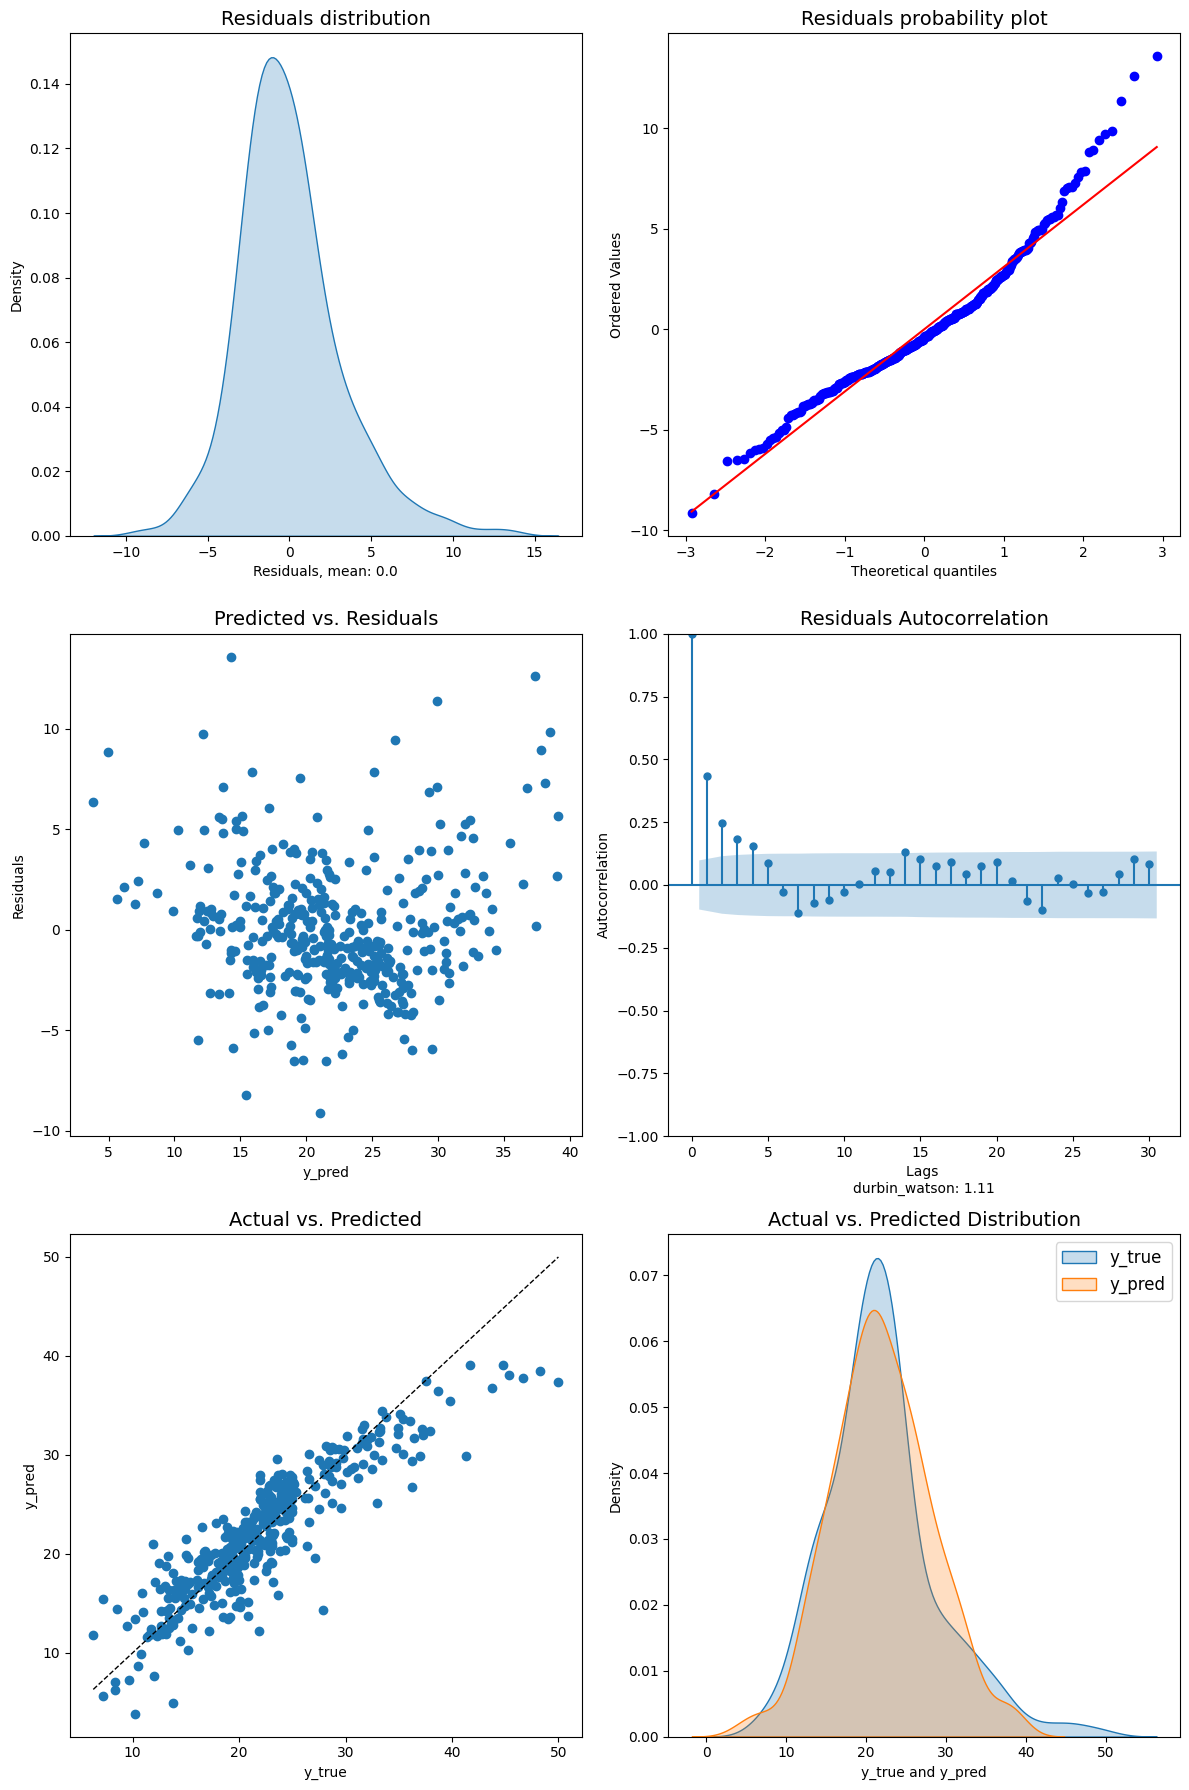

In [ ]:
diagnostics(y, y_pred)

Разберем полученную информацию:
* в целом остатки модели распределены нормально с нулевым средним
значением;
* явной гетероскедастичности нет, хотя мы видим, что дисперсия не всегда
равномерна;
* присутствует умеренная отрицательная корреляция;
* график y_true vs. y_pred показывает, насколько сильно прогнозные значения
отклоняются от фактических; в идеальной модели (без шума, т.е. без
случайных колебаний) точки должны были бы находиться на диагонали, в
более реалистичной модели нам бы хотелось видеть, что точки плотно
сосредоточены вокруг диагонали;
* распределение прогнозных значений в целом повторяет распределение
фактических.

#### Мультиколлинеарность
Отдельно проведем анализ на мультиколлинеарность. Напишем соответствующую
функцию.

In [ ]:
def vif(df, features):
    vif, tolerance = {}, {}

    # пройдемся по интересующим нас признакам
    for feature in features:
        # составим список остальных признаков, которые будем использовать
        # для построения регрессии
        X = [f for f in features if f != feature]
        # поместим текущие признаки и таргет в X и y
        X, y = df[X], df[feature]
        # найдем коэффициент детерминации
        r2 = LinearRegression().fit(X, y).score(X, y)

        # посчитаем tolerance
        tolerance[feature] = 1 - r2
        # найдем VIF
        vif[feature] = 1 / (tolerance[feature])

    # выведем результат в виде датафрейма
    return pd.DataFrame({'VIF': vif, 'Tolerance': tolerance})

In [ ]:
vif(df = X.drop('CHAS', axis = 1), features = X.drop('CHAS', axis = 1).columns)

,VIF,Tolerance
CRIM,3.737294,0.267573
ZN,1.877035,0.532755
INDUS,3.538363,0.282617
NOX,5.169705,0.193435
RM,1.955011,0.511506
AGE,3.022372,0.330866
DIS,3.394467,0.294597
RAD,8.831025,0.113237
TAX,8.615462,0.116070
PTRATIO,1.463141,0.683461


### Дополнительная обработка данных
Попробуем дополнительно улучшить некоторые из диагностических показателей.

#### VIF
Уберем признак с наибольшим VIF (RAD) и посмотрим, что получится.

In [ ]:
# удалим RAD и посмотрим, как изменится VIF
vif(df = X, features = ['CRIM',
                        'ZN',
                        'INDUS',
                        'CHAS',
                        'NOX',
                        'RM',
                        'AGE',
                        'DIS',
                        'TAX',
                        'PTRATIO',
                        'B',
                        'LSTAT'])

,VIF,Tolerance
CRIM,2.943153,0.339772
ZN,1.865450,0.536064
INDUS,3.405180,0.293670
CHAS,1.045405,0.956567
NOX,5.019761,0.199213
RM,1.915038,0.522183
AGE,2.981066,0.335450
DIS,3.379355,0.295914
TAX,4.427160,0.225878
PTRATIO,1.450312,0.689507


Показатели пришли в норму. Окончательно удалим RAD.

In [ ]:
boston.drop(columns = 'RAD', inplace = True)

#### Преобразование данных
Применим преобразование Йео-Джонсона (Преобразование данных. Часть 2).

In [ ]:
from sklearn.preprocessing import PowerTransformer

pt = PowerTransformer()
boston = pd.DataFrame(pt.fit_transform(boston),
                      columns = boston.columns)

### Отбор признаков
Посмотрим на линейную корреляцию Пирсона количественных признаков и
целевой переменной.

In [ ]:
boston.drop(columns = 'CHAS').corr().MEDV.to_frame().style.background_gradient()

,MEDV
CRIM,-0.594325
ZN,0.356857
INDUS,-0.598651
NOX,-0.571662
RM,0.621965
AGE,-0.548476
DIS,0.435669
TAX,-0.587527
PTRATIO,-0.552881
B,0.244196


Также рассчитаем точечно-бисериальную корреляцию.

In [ ]:
pbc(boston.MEDV, boston.CHAS)

np.float64(0.11362001957976946)

Удалим признаки с наименьшей корреляцией, а именно ZN, CHAS, DIS и B.

In [ ]:
boston.drop(columns = ['ZN', 'CHAS', 'DIS', 'B'], inplace = True)

### Повторное моделирование и диагностика

#### Повторное моделирование
Выполним повторное моделирование.

In [ ]:
X = boston.drop(columns = 'MEDV')
y = boston.MEDV

from sklearn.linear_model import LinearRegression

model = LinearRegression()
y_pred = model.fit(X, y).predict(X)

#### Оценка качества и диагностика

Оценим качество. Так как мы преобразовали целевую переменную, показатель
RMSE не будет репрезентативен. Воспользуемся MAPE и $R^2.$

In [ ]:
mape(y, y_pred)

9.427283299458752

In [ ]:
r_squared(X, y, y_pred)

(np.float64(0.7546883769480334), np.float64(0.7546883769480334))

Отклонение прогнозного значения от истинного снизилось. $R^2$ немного
уменьшился, чтобы бывает, когда мы пытаемся привести модель в соответствие
допущениям. Проведем диагностику.

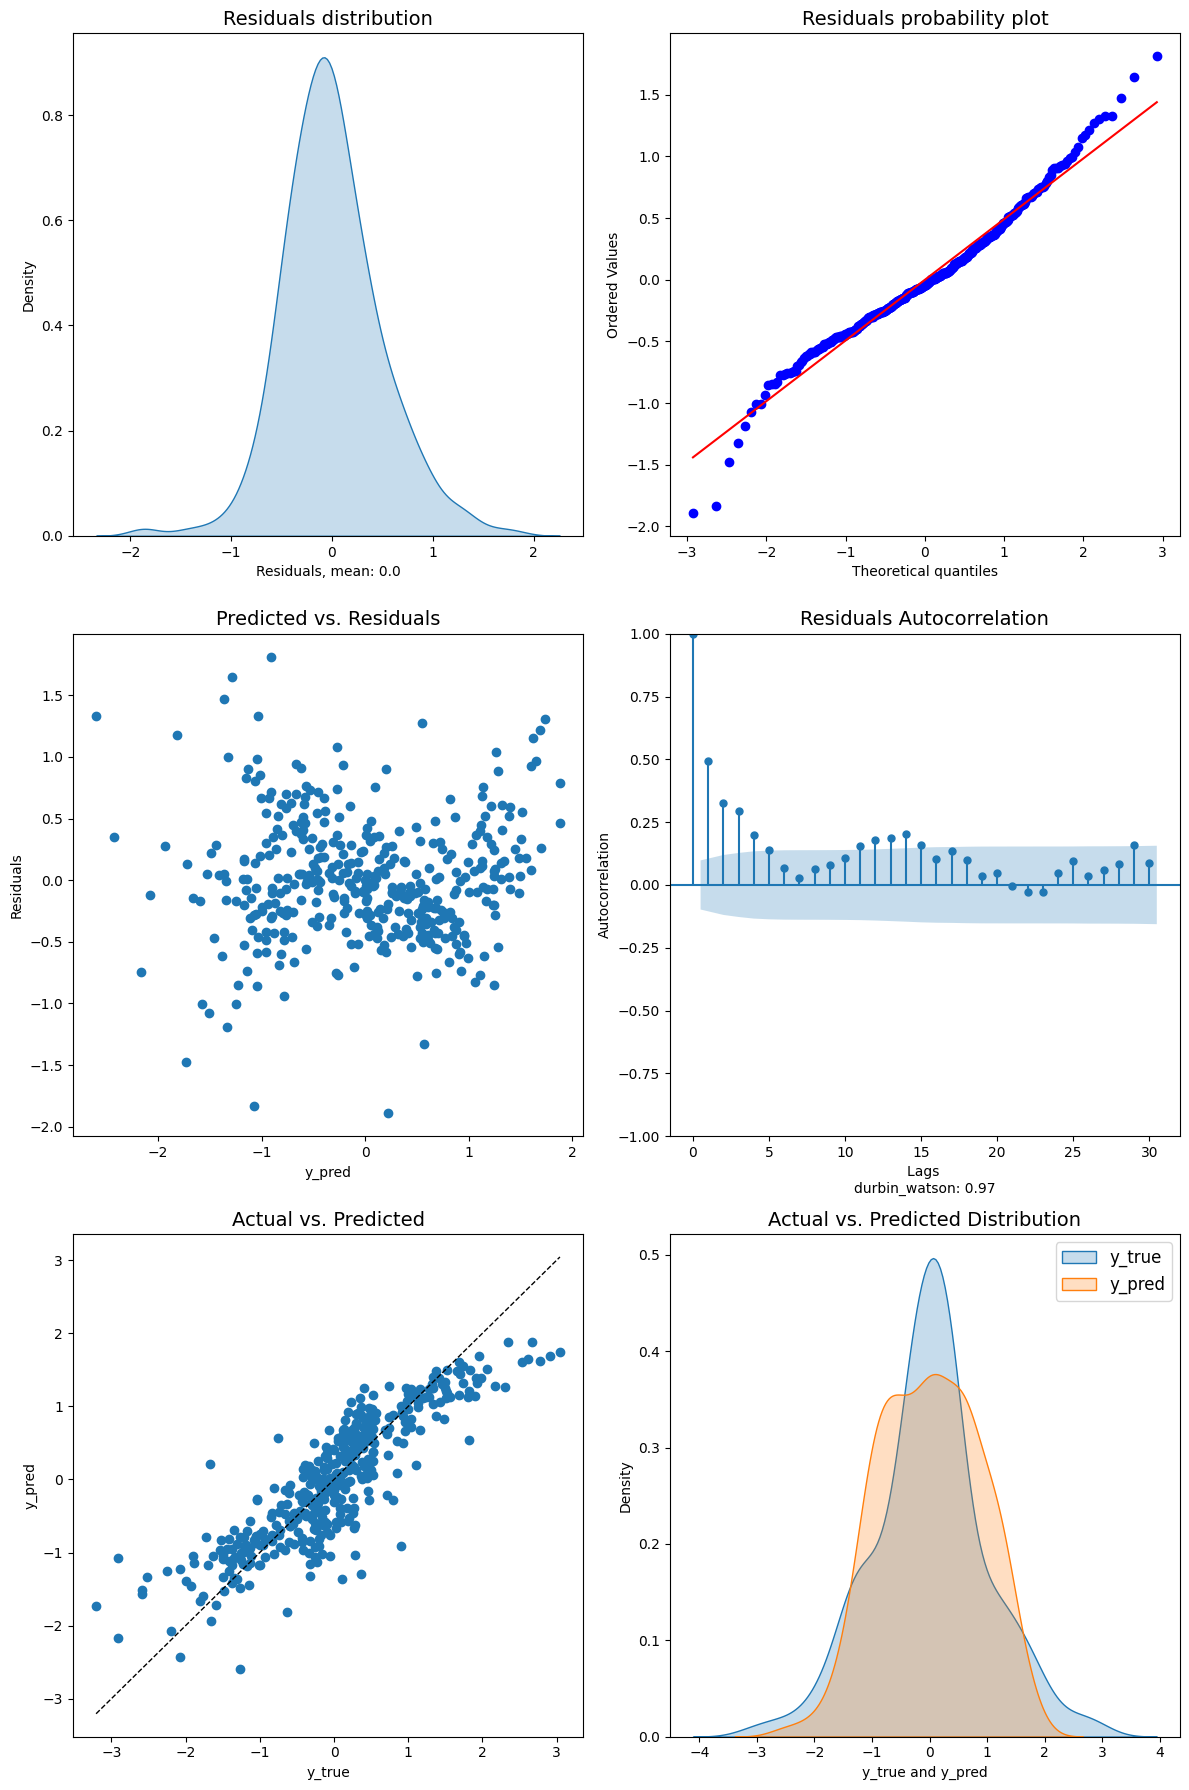

In [ ]:
diagnostics(y, y_pred)

Распределение остатков немного улучшилось, при этом незначительно усилилась их отрицательная автокорреляция. Распределение целевой переменной стало менее
островершинным.


Данные можно было бы продолжить анализировать и улучшать, однако в рамках
текущего занятия перейдем к механике обучения модели.

#### Коэффициенты
Выведем коэффициенты для того, чтобы сравнивать их с результатами
построенных с нуля моделей.

In [ ]:
model.intercept_, model.coef_

(np.float64(9.814355121781304e-16),
 array([-0.09989392,  0.03965441,  0.1069877 ,  0.23172172, -0.05561128,
        -0.16878987, -0.18057055, -0.49319274]))

## Обучение модели
Теперь, когда мы поближе познакомились с понятием регрессии, разобрали
функции потерь и изучили допущения, при которых модель может быть удачной
аппроксимацией данных, пора перейти к непосредственному созданию алгоритмов.
### Векторизация уравнения
Для удобства векторизуем приведенное ранее уравнение множественной линейной
регрессии.

$$ \mathbf y = \begin{bmatrix} y_1 \\ y_2 \\ \vdots \\ y_n \end{bmatrix}, \: \mathbf X =
\begin{bmatrix} x_{00} & x_{01} & \ldots & x_{0j} \\ x_{10} & x_{11} & \ldots &
x_{1j} \\ \vdots & \vdots & \ddots & \vdots \\ x_{n0} & x_{n1} & \ldots & x_{n,d}
\end{bmatrix}, \: \boldsymbol \theta = \begin{bmatrix} \theta_0 \\ \theta_1 \\ \vdots \\
\theta_n \end{bmatrix}, \: \boldsymbol \varepsilon = \begin{bmatrix} \varepsilon_1 \\
\varepsilon_2 \\ \vdots \\ \varepsilon_n \end{bmatrix} $$

где $n$ — количество наблюдений, а $d$ — количество признаков.

Обратите внимание, что мы создали еще один столбец данных $ x_0,$ который
будем умножать на сдвиг $ \theta_0.$ Его мы заполним единицами.

В результате такого несложного преобразования значение сдвига не изменится, но
мы сможем записать уравнение через умножение матрицы на вектор.

$$ \mathbf y = \mathbf X \boldsymbol \theta + \boldsymbol \varepsilon $$

Кроме того, как мы увидим ниже, так нам не придется искать отдельную
производную для коэффициента $ \theta_0 .$

Схематично для модели с четырьмя наблюдениями, $n = 4,$ и двумя признаками,
$d = 2,$ построение прогноза будет выглядеть следующим образом.

![](https://drive.google.com/uc?export=view&id=19kExTqcsw1SI0tieiCgBN3mXQy5Gg8z1)




### Функции потерь
Как мы уже говорили, чтобы подобрать оптимальные коэффициенты $\theta$, нам
нужен критерий или функция потерь. Логично измерять отклонение прогнозного
значения от истинного.

$$ \boldsymbol \varepsilon = \mathbf X \boldsymbol \theta-\mathbf y $$

При этом опять же просто складывать отклонения или ошибки мы не можем.
Положительные и отрицательные значения будут взаимоудаляться. Для решения
этой проблемы можно, например, использовать модуль числа, и это приводит нас к
абсолютной ошибке или L1 loss.

#### Абсолютная ошибка, L1 loss

При усреднении на количество наблюдений мы получаем среднюю абсолютную
ошибку (mean absolute error, MAE).

$$ MAE = \frac{\sum{|\mathbf y-\mathbf X \boldsymbol \theta|}}{n} =
\frac{\sum{|\boldsymbol \varepsilon|}}{n} $$

Приведем пример такой функции на Питоне.

In [ ]:
def L1(y_true, y_pred):
  return np.sum(np.abs(y_true - y_pred)) / y_true.size

Помимо модуля ошибку можно возводить в квадрат.
#### Квадрат ошибки, L2 loss
В этом случай говорят про сумму квадратов ошибок (sum of squared errors, SSE) или
сумму квадратов остатков (sum of squared residuals, SSR или residual sum of squares,
RSS).

$$ SSE = \sum (\mathbf y-\mathbf X \boldsymbol \theta)^2 $$

Как мы уже знаем, на практике вместо SSE часто используется MSE, или вернее
half MSE для удобства нахождения производной.

$$ MSE = \frac{1}{2n} \sum (\mathbf y-\boldsymbol \theta \mathbf X)^2 $$

Ниже код на Питоне.

In [ ]:
def L2(y_true, y_pred):
  return np.sum((y_true - y_pred) ** 2) / y_true.size

На практике у обеих функций есть сильные и слабые стороны. Рассмотрим L1 loss
(MAE) и L2 loss (MSE) на графике.

Представим обе функции на графике

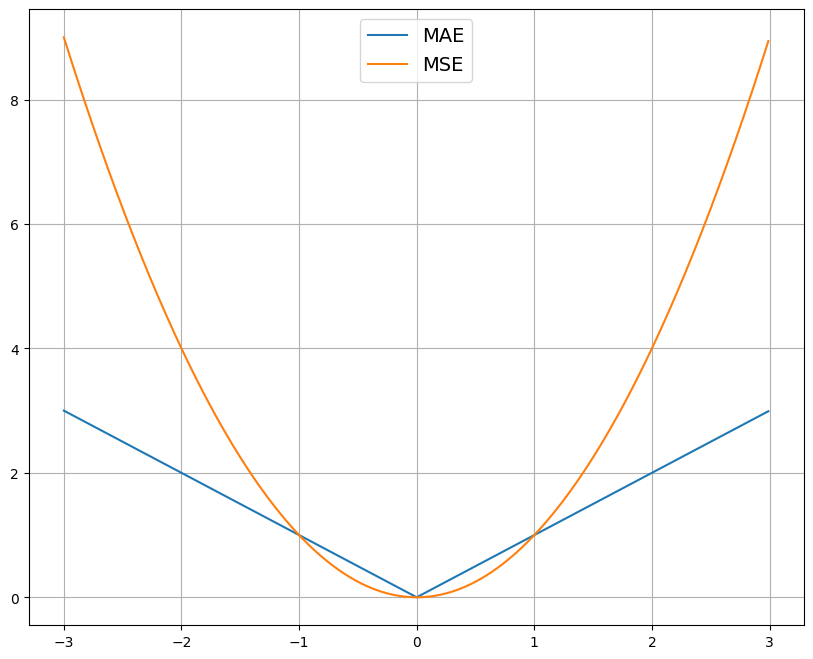

In [ ]:
# для построения графиков мы используем x вместо y_true, y_pred
# в качестве входящего значения
def mse(x):
  return x ** 2

def mae(x):
  return np.abs(x)

plt.figure(figsize = (10, 8))

x_vals = np.arange(-3, 3, 0.01)

plt.plot(x_vals, mae(x_vals), label = 'MAE')
plt.plot(x_vals, mse(x_vals), label = 'MSE')

plt.legend(loc = 'upper center', prop = {'size': 14})
plt.grid()
plt.show()

Очевидно, при отклонении от точки минимума из-за возведения в квадрат L2
значительно быстрее увеличивает ошибку, поэтому если в данных есть выбросы
при суммированнии, они очень сильно влияют на этот показатель, хотя де-факто
бо́льшая часть значений такого уровня потерь не дали бы.

Функция L1 не дает такой большой ошибки на выбросах, однако ее сложно
дифференцировать, в точке минимума ее производная не определена.

#### Huber loss Функция Хьюбера
Рассмотрим функцию Хьюбера (Huber loss), которая объединяет сильные стороны
вышеупомянутых функций и при этом лишена их недостатков. Посмотрим на
формулу.

$$ L_{\delta}= \left\{\begin{array}{ll} \frac{1}{2}(y-\hat{y})^{2} & \text{if } | y-
\hat{y} | < \delta \\ \delta (|y-\hat{y}|-\frac1 2 \delta) & \text{otherwise}
\end{array}\right. $$

Построим функцию на графике

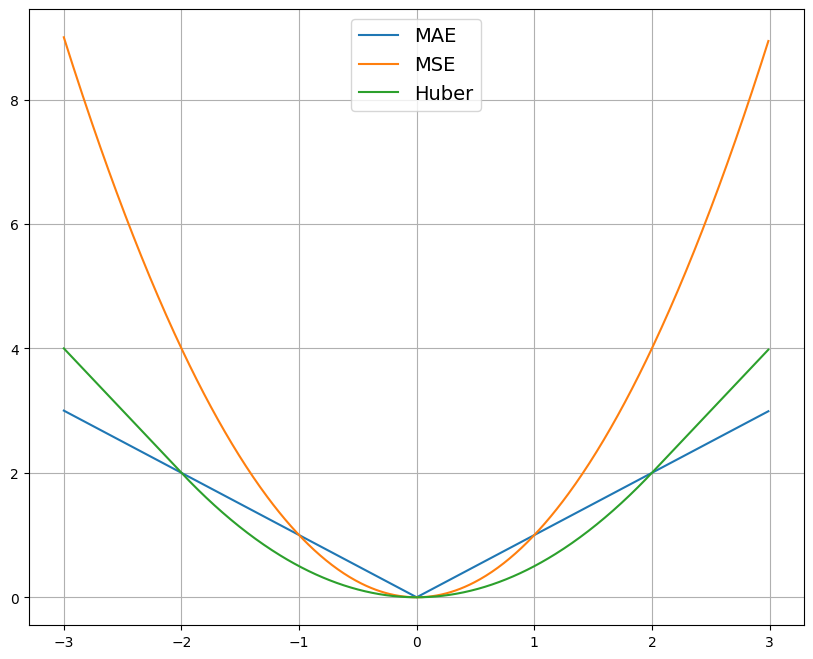

In [ ]:
plt.figure(figsize = (10, 8))

def huber(x, delta = 1.):
  huber_mse = 0.5 * np.square(x)
  huber_mae = delta * (np.abs(x) - 0.5 * delta)
  return np.where(np.abs(x) <= delta, huber_mse, huber_mae)

x_vals = np.arange(-3, 3, 0.01)

plt.plot(x_vals, mae(x_vals), label = 'MAE')
plt.plot(x_vals, mse(x_vals), label = 'MSE')
plt.plot(x_vals, huber(x_vals, delta = 2), label = 'Huber')

plt.legend(loc = 'upper center', prop = {'size': 14})
plt.grid()
plt.show()

Также приведем код этой функции.

In [ ]:
def huber(y_pred, y_true, delta = 1.0):
  # пропишем обе части функции потерь
  huber_mse = 0.5 * (y_true - y_pred) ** 2
  huber_mae = delta * (np.abs(y_true - y_pred) - 0.5 * delta)
  # выберем одну из них в зависимости от дельта
  return np.where(np.abs(y_true - y_pred) <= delta, huber_mse, huber_mae)

На сегодняшнем занятии мы, как и раньше, в качестве функции потерь используем
MSE.

### Метод наименьших квадратов

####Нормальные уравнения
Для множественной линейной регрессии коэффициенты находятся по следующей
формуле
$$ \boldsymbol \theta = (\mathbf X^\top \mathbf X)^{-1} \mathbf X^\top \mathbf y $$
Разберем эту формулу подробнее. Сумму квадратов остатков (SSE) можно
переписать как произведение вектора $ \boldsymbol \varepsilon $ на самого себя, то
есть $ SSE = \boldsymbol \varepsilon^\top \boldsymbol \varepsilon$. Помня, что
$\boldsymbol \varepsilon = \mathbf y-\mathbf X \boldsymbol \theta $ получаем (не
забывая транспонировать)

$$ (\mathbf y-\mathbf X \boldsymbol \theta)^\top (\mathbf y-\mathbf X \boldsymbol
\theta) $$

$$ \mathbf y^\top \mathbf y-\mathbf y^\top (\mathbf X \boldsymbol \theta)-(\mathbf X
\boldsymbol \theta)^\top \mathbf y+(\mathbf X \boldsymbol \theta)^\top (\mathbf X
\boldsymbol \theta) $$

Заметим, что $\mathbf A^\top \mathbf B = \mathbf B^\top \mathbf A$, тогда

$$ \mathbf y^\top \mathbf y-(\mathbf X \boldsymbol \theta)^\top \mathbf y-(\mathbf X
\boldsymbol \theta)^\top \mathbf y+(\mathbf X \boldsymbol \theta)^\top (\mathbf X
\boldsymbol \theta)$$

$$ \mathbf y^\top \mathbf y-2(\mathbf X \boldsymbol \theta)^\top \mathbf y+(\mathbf X\boldsymbol \theta)^\top (\mathbf X \boldsymbol \theta) $$

Вспомним, что $ (\mathbf A \mathbf B)^\top = \mathbf B^\top \mathbf A^\top $, тогда

$$ \mathbf y^\top \mathbf y-2 \boldsymbol \theta^\top \mathbf X^\top \mathbf y+
\boldsymbol \theta^\top \mathbf X^\top \mathbf X \boldsymbol \theta $$

Теперь нужно найти градиент этой функции

$$ \nabla_{J(\theta)} \left( \mathbf y^\top \mathbf y-2 \boldsymbol \theta^\top X^\top
\mathbf y+\theta^\top \mathbf X^\top \mathbf X \boldsymbol \theta \right) $$

После дифференцирования относительно $\theta$ мы получаем следующий
результат

$$ \nabla_{J(\theta)} = -2\mathbf X^\top \mathbf y+2 \mathbf X^\top \mathbf X
\boldsymbol \theta $$

Как мы помним, оптимум функции находится там, где производная равна нулю.

$$ -2 \mathbf X^\top \mathbf y+2 \mathbf X^\top \mathbf X \boldsymbol \theta = 0 $$

$$ -\mathbf X \top \mathbf y+\mathbf X^\top \mathbf X \boldsymbol \theta = 0 $$

$$ \mathbf X^\top \mathbf X \boldsymbol \theta = \mathbf X^\top \mathbf y $$

Выражение выше называется нормальным уравнением (normal equation).
Решив его для $\boldsymbol \theta,$ мы найдем аналитическое решение
минимизации суммы квадратов отклонений.

$$ \boldsymbol \theta = (\mathbf X^\top
 \mathbf X)^{-1}\mathbf X^\top \mathbf y $$

По теореме Гаусса-Маркова, оценка через МНК является наиболее
оптимальной (обладающей наименьшей дисперсией) среди всех методов
построения модели.

#### Построение модели Код на Питоне
Перейдем к созданию класса линейной регрессии наподобие LinearRegression
библиотеки sklearn. Вначале напишем функцию гипотезы (т.е. функцию самой
модели), снабдив ее еще одной функцией, которая добавляет столбец из единиц к
признакам.

$$ h_{\theta}(x) = \mathbf X \boldsymbol \theta $$

In [ ]:
def add_ones(x):
  # важно! изменяет исходный датафрейм
  return x.insert(0,'x0', np.ones(x.shape[0]))

In [ ]:
def h(x, theta):
  x = x.copy()
  add_ones(x)
  return np.dot(x, theta)

Перейдем к функции, отвечающей за обучение модели.
$$ \theta = (X^TX)^{-1} X^Ty $$

In [ ]:
# строчную x используем внутри функций и методов класса
# заглавную X вне функций и методов
def fit(x, y):
  x = x.copy()
  add_ones(x)
  xT = x.transpose()

  inversed = np.linalg.inv(np.dot(xT, x))
  thetas = inversed.dot(xT).dot(y)

  return thetas

Обучим модель и выведем коэффициенты.

In [ ]:
thetas = fit(X, y)
thetas[0], thetas[1:]

(np.float64(9.237402509576498e-16),
 array([-0.09989392,  0.03965441,  0.1069877 ,  0.23172172, -0.05561128,
        -0.16878987, -0.18057055, -0.49319274]))

Примечание. Замечу, что не все матрицы обратимы. В этом случае можно найти
псевдообратную матрицу (pseudoinverse). Для этого в Numpy есть **функция np.linalg.pinv()**.

#### Прогноз

In [ ]:
y_pred = h(X, thetas)
y_pred[:5]

array([1.24414665, 0.55999778, 1.48103299, 1.49481605, 1.21342788])

#### Создание класса

Объединим код в класс.

In [ ]:
class Ols():
  def __init__(self):
    self.thetas = None

  def add_ones(self, x):
    return x.insert(0,'x0', np.ones(x.shape[0]))

  def fit(self, x, y):
    x = x.copy()
    self.add_ones(x)
    xT = x.T

    inversed = np.linalg.inv(np.dot(xT, x))
    self.thetas = inversed.dot(xT).dot(y)

  def predict(self, x):
    x = x.copy()
    self.add_ones(x)
    return np.dot(x, self.thetas)

Создадим объект класса и обучим модель.

In [ ]:
model = Ols()

model.fit(X, y)

Выведем коэффициенты.

In [ ]:
model.thetas[0], model.thetas[1:]

(np.float64(9.237402509576498e-16),
 array([-0.09989392,  0.03965441,  0.1069877 ,  0.23172172, -0.05561128,
        -0.16878987, -0.18057055, -0.49319274]))

Сделаем прогноз.

In [ ]:
y_pred = model.predict(X)
y_pred[:5]

array([1.24414665, 0.55999778, 1.48103299, 1.49481605, 1.21342788])

#### Оценка качества

Оценим качество через MAPE и $R^2$.

In [ ]:
mape(y, y_pred)

np.float64(9.427283299458765)

In [ ]:
r_squared(X, y, y_pred)

(np.float64(0.7546883769480335), np.float64(0.7546883769480335))

Мы видим, что результаты аналогичны.

### Метод градиентного спуска
В целом с этим методом мы уже хорошо знакомы. В качестве упражнения давайте
реализуем этот алгоритм на Питоне для многомерных данных.
#### Нахождение градиента
Покажем расчет градиента на схеме.

![](https://drive.google.com/uc?export=view&id=1Is3y75eVB57j9raB5GopQJ5PtjzGFJfe)

В данном случае мы берем датасет из четырех наблюдений и двух признаков $x_1$
и $x_2,$ и соответственно используем три коэффициента $\theta_0, \theta_1$ и
$\theta_2.$

#### Пошаговое построение модели
Начнем с функции гипотезы.

$$ h_{\theta}(x) = \mathbf X \boldsymbol \theta $$

In [ ]:
def h(x, thetas):
  return np.dot(x, thetas)

Объявим функцию потерь.
$$ J({\theta_j}) = \frac{1}{2n} \sum (\mathbf y-\mathbf X \boldsymbol \theta)^2 $$

In [ ]:
def objective(x, y, thetas, n):
  return np.sum((y - h(x, thetas)) ** 2) / (2 * n)

Найдем частную производную для каждого $j$ признака.
$$ \frac{\partial J}{\partial \theta_j} = -\mathbf X(\mathbf y-\mathbf X
\theta_j) \times \frac{1}{n} = \mathbf X(\mathbf X \theta_j-\mathbf y) \times \frac{1}{n}
$$

Градиент (совокупность этих производных) будет иметь вид

$$ \nabla_{\theta} J = \mathbf X^\top (\mathbf X \boldsymbol \theta-\mathbf y)
\times \frac{1}{n} $$

Примечание. В данном случае оператор $\cdot$ означает скалярное произведение, а
$\times$ — произведение Адамара.

In [ ]:
def gradient(x, y, thetas, n):
  return np.dot(x.T, (h(x, thetas) - y)) * (1/n)

Напишем функцию для обучения модели.

$$ \boldsymbol \theta^{t+1} := \boldsymbol \theta^t-\alpha \nabla_{\theta} J $$

Символ $:=$ означает, что левая часть равенства определяется правой. Другими
словами, с каждой итерацией $t$ мы обновляем веса, умножая коэффициент
скорости обучения на градиент.

In [ ]:
def fit(x, y, iter = 20000, learning_rate = 0.05):
  x, y = x.copy(), y.copy()

  # функцию add_ones() мы объявили выше
  add_ones(x)

  thetas, n = np.zeros(x.shape[1]), x.shape[0]

  loss_history = []

  for i in range(iter):
    loss_history.append(objective(x, y, thetas, n))
    grad = gradient(x, y, thetas, n)
    thetas -= learning_rate * grad

  return thetas, loss_history

Обучим модель, выведем коэффициенты и достигнутый (минимальный) уровень ошибки.

In [ ]:
thetas, loss_history = fit(X, y, iter = 50000, learning_rate = 0.05)

In [ ]:
thetas[0], thetas[1:], loss_history[-1]

(np.float64(9.576364024596306e-16),
 array([-0.09989392,  0.03965441,  0.1069877 ,  0.23172172, -0.05561128,
        -0.16878987, -0.18057055, -0.49319274]),
 np.float64(0.12265581152598336))

Полученный результат очень близок к тому, что было найдено методом
наименьших квадратов.

#### Прогноз
Сделаем прогноз.

In [ ]:
def predict(x, thetas):
  x = x.copy()
  add_ones(x)
  return np.dot(x, thetas)

In [ ]:
y_pred = predict(X, thetas)
y_pred[:5]

array([1.24414665, 0.55999778, 1.48103299, 1.49481605, 1.21342788])

#### Создание класса
Объединим написанные функции в класс.

In [ ]:
class Gd():
  def __init__(self):
    self.thetas = None
    self.loss_history = []

  def add_ones(self, x):
    return x.insert(0,'x0', np.ones(x.shape[0]))

  def objective(self, x, y, thetas, n):
    return np.sum((y - self.h(x, thetas)) ** 2) / (2 * n)

  def h(self, x, thetas):
    return np.dot(x, thetas)

  def gradient(self, x, y, thetas, n):
    return np.dot(x.T, (self.h(x, thetas) - y)) * (1/n)

  def fit(self, x, y, iter = 20000, learning_rate = 0.05):
    x, y = x.copy(), y.copy()
    self.add_ones(x)

    thetas, n = np.zeros(x.shape[1]), x.shape[0]

    loss_history = []

    for i in range(iter):
      loss_history.append(self.objective(x, y, thetas, n))
      grad = self.gradient(x, y, thetas, n)
      thetas -= learning_rate * grad

    self.thetas = thetas
    self.loss_history = loss_history

  def predict(self, x):
    x = x.copy()
    self.add_ones(x)
    return np.dot(x, self.thetas)

Создадим объект класса, обучим модель, выведем коэффициенты и сделаем
прогноз.

In [71]:
model = Gd()

model.fit(X, y, iter = 50000, learning_rate = 0.05)

model.thetas[0], model.thetas[1:], model.loss_history[-1]

(np.float64(9.576364024596306e-16),
 array([-0.09989392,  0.03965441,  0.1069877 ,  0.23172172, -0.05561128,
        -0.16878987, -0.18057055, -0.49319274]),
 np.float64(0.12265581152598336))

In [ ]:
y_pred = model.predict(X)
y_pred[:5]

array([1.24414665, 0.55999778, 1.48103299, 1.49481605, 1.21342788])

#### Оценка качества

In [ ]:
mape(y, y_pred)

9.427283299458702

In [ ]:
r_squared(X, y, y_pred)

(0.7546883769480334, 0.7546883769480334)

#### Диагностика алгоритма
Работу алгоритма можно проверить с помощью кривой обучения (learning curve), на
которой мы должны увидеть, что:
* ошибка постоянно снижается;
* алгоритм остановится после истечения заданного количества итераций.

При этом можно также задать пороговое значение ошибки, после которого
обновление весов прекратится. Построим кривую обучения.

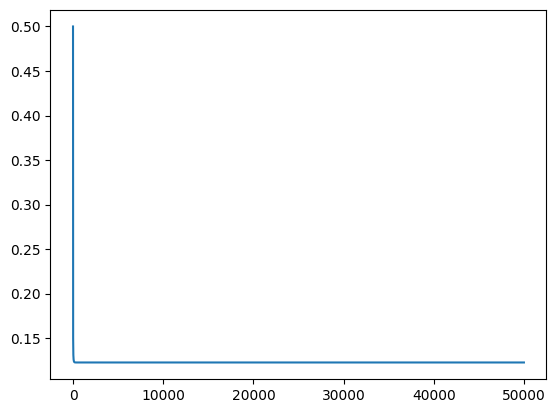

In [72]:
plt.plot(loss_history);

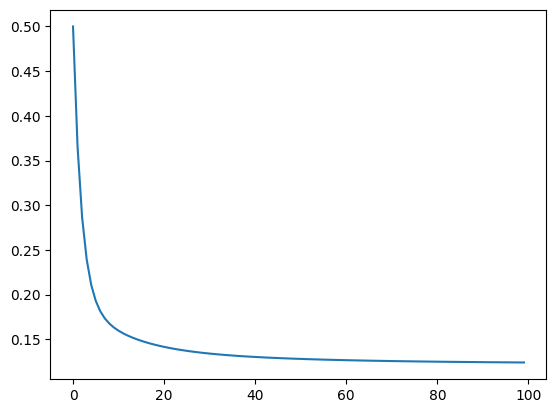

In [73]:
plt.plot(loss_history[:100]);

График также позволяет выбрать адекватный коэффициент скорости обучения.

# Линейная регрессия. Часть 3
Продолжим изучать линейную регрессию.
## Линейная регрессия как проекция
Представим данные как систему линейных уравнений.

![](https://drive.google.com/uc?export=view&id=1-_YK4Mu7zQmxIIyZz4Onc-8yqLE268Ct)

На рисунке выше представлена обычная задача простой линейной регрессии с
немного измененной нотацией. У нас есть пять наблюдений, каждое наблюдение
описано признаками $a_0$ и $a_1,$ при этом $a_0$ заполнен единицами. Подставив
некоторые веса $\theta_0$ и $\theta_1,$ мы получим для каждой точки значение
целевой переменной $b$ (ранее мы ее обозначали через $y$).

Единственного решения для такой системы не существует, поскольку мы не
сможем подобрать такие $\theta_0$ и $\theta_1,$ которые бы удовлетворяли всем
$a_0$ и $a_1$ в каждой строке (для каждого наблюдения).

Такая система уравнений называется **переопределенной** (overdetermined). Она
содержит пять уравнений (наблюдений) и при двух неизвестных (коэффициентах).
Можно также сказать, что мы наложили слишком много ограничений (ограничения,
в данном случае, это уравнения), чтобы найти единственное решение.

Перепишем эту систему с помощью векторов и матриц. В общем случае у нас
конечно может быть больше признаков $\mathbf a_0, \mathbf a_1, \mathbf a_2,..,
\mathbf a_d,$ однако систему по-прежнему будем считать переопределенной, то
есть $n > d.$ Также заменим $\boldsymbol \theta$ на $\mathbf x.$

$$ \begin{bmatrix} \vdots & \vdots & \vdots & \vdots \\ \mathbf a_1 & \mathbf a_2 &
\dots & \mathbf a_d \\ \vdots & \vdots & \vdots & \vdots \end{bmatrix} \begin{bmatrix}
x_1 \\ x_2 \\ \vdots \\ x_d \end{bmatrix} = \begin{bmatrix} b_1 \\ b_2 \\ \vdots \\ b_n
\end{bmatrix} $$

$$ \underset{n \times d}{ \mathbf A} \mathbf x = \mathbf b $$

При этом в данном случае $\mathbf A, \mathbf x \in \mathbb{R}^d$, а $\mathbf b \in
\mathbb{R}^n.$ То есть вектор $\mathbf b$ находится в пространстве большей
размерности, чем $\mathbf {x}.$ Например, вектор $\mathbf x$ может находиться на
плоскости (двумерный вектор), а вектор $\mathbf b$ в трехмерном пространстве.

![](https://drive.google.com/uc?export=view&id=14L2WSqRN1lLW-L4lLZTMkK82Bbq9LCob)

Можно также сказать, что не существует линейной комбинации значений вектора
$\mathbf x$ (веса модели) и векторов $\mathbf a_0, \mathbf a_1, \mathbf a_2,..,
\mathbf a_d,$ которые преобразовывались бы в вектор $\mathbf {b}.$

$$ x_1 \mathbf a_1 + x_2 \mathbf a_2 + x_3 \mathbf a_3 + … + x_d \mathbf a_d \not=
\mathbf b $$

Наконец, справедливо, что $ \mathbf b $ не находится в пространстве столбцов
$\mathbf A,$ $\mathbf b \not\in col(\mathbf A)$ (то есть не находится на плоскости), а
вектор $ \mathbf x $ как раз лежит на этой плоскости, и это значит, что мы никак не
можем перевести с помощью матрицы $\mathbf A$ вектор $ \mathbf x $ из
двумерного пространства в трехмерное.

С другой стороны, мы можем попробовать получить наилучшее возможное
решение, найдя такой вектор $ \mathbf x^*{,} $ который будет максимально
приближен к вектору $ \mathbf b $ (т.е. будет иметь минимальное расстояние до
него). Расстояние же между векторами можно определить как разницу двух
векторов.

Для того чтобы положительные и отрицательные значения не взаимоудалялись,
возведем значения в квадрат.

$$ min || \mathbf b-\mathbf A \mathbf x^* ||^2 $$

Очевидно, что вектор (назовем его $ \mathbf p $), получившийся в результате
$\mathbf A \mathbf x^*$ будет в пространстве $\mathbb{R}^d,$ что то же самое, что
$ \mathbf p \in col(\mathbf A) $ (то есть в данном случае на плоскости).

![](https://drive.google.com/uc?export=view&id=1-60g4jFhSFtGMPSreIwV2Xfmfk3EMw2q)

Далее, наименьшее расстояние от вектора $ \mathbf b $ до $ \mathbf p $ можно
определить как ортогональную проекцию $ \mathbf b $ на пространство столбцов
$\mathbf A.$

$$ \mathbf A \mathbf x^* = \mathbf p = proj_{col(A)} \mathbf b $$

Попробуем найти решение относительно $\mathbf b.$

$$ \mathbf A \mathbf x^* = proj_{col(A)} \mathbf b $$

Вычтем вектор $\mathbf b$ из обеих частей.

$$ \mathbf A \mathbf x^*-\mathbf b = proj_{col(A)} \mathbf b-\mathbf b $$

Заметим, что вектор $ proj_{col(A)} \mathbf b-\mathbf b $ (на рисунке представлен
красным вектором) ортогонален к плоскости $col(\mathbf A)$. Как следствие,
$\mathbf A \mathbf x^*-\mathbf b$ ортогонально $col(\mathbf A).$

Можно также сказать, что $\mathbf A \mathbf x^*-\mathbf b$ является
ортогональным дополнением пространства $col(\mathbf A).$ Запишем это как
$\mathbf A \mathbf x^*-\mathbf b = col(\mathbf A)^{\perp}.$

Одновременно ортогональное дополнение пространства столбцов матрицы $\mathbf
A$ равно ядру $\mathbf A^\top$, то есть $col(\mathbf A)^{\perp} = null(\mathbf
A^\top)$. Тогда,

$$ \mathbf A \mathbf x^*-\mathbf b \in null(\mathbf A^\top) $$

Если умножить матрицу $\mathbf A^\top$ на ее ядро $ \mathbf A \mathbf x^*-\mathbf
{b}, $ то мы получим нулевой вектор.

$$ \mathbf A^\top (\mathbf A \mathbf x^*-\mathbf b) = \mathbf 0 $$

$$ \mathbf A^\top \mathbf A \mathbf x^*-\mathbf A^\top \mathbf b = \mathbf 0 $$

$$ \mathbf A^\top \mathbf A \mathbf x^* = \mathbf A^\top \mathbf b $$

Таким образом можно найти $\mathbf x^*,$ которое минимизирует квадрат
расстояния между вектором $ \mathbf b $ и вектором проекции $\mathbf A \mathbf
x^*.$

Уверен, вы узнали в этом выражении нормальные уравнения, о которых мы
говорили на занятии по линейной регрессии.

$$ \mathbf X^\top \mathbf X \boldsymbol \theta = \mathbf X^\top \mathbf y $$

Нормальными же эти уравнения называются, потому что $ \mathbf A \mathbf x^*-
\mathbf b \perp col(\mathbf A), $ а нормалью в геометрии как раз считается обобщенное понятие перпендикуляра к поверхности.

Более того, можно сказать, что минимизация расстояний от точек до прямой вдоль оси y одновременно приводит к минимизации длины перпендикуляров к проекциям
точек.

![](https://drive.google.com/uc?export=view&id=1ocDn3Mk1sbk-Q8lAT-GJAUDoSm7evNkR)




#### Пример
Возьмем систему уравнений.

$$ \begin{cases} 2x &-& y &=& 2 \\ x &+& 2y &=& 1 \\ x &+& y &=& 4 \end{cases}
$$

Такая система опять же могла бы описывать данные, где x и y представляют собой
некоторые коэффициенты (без сдвига, например, $\theta_1$ и $\theta_2$), а сами
уравнения — объекты (наблюдения).

Убедимся, что нам не удастся найти x и y, которые бы удовлетворяли каждому из
уравнений, построив соответствующие прямые на графике (для этого решим
уравнения относительно y).

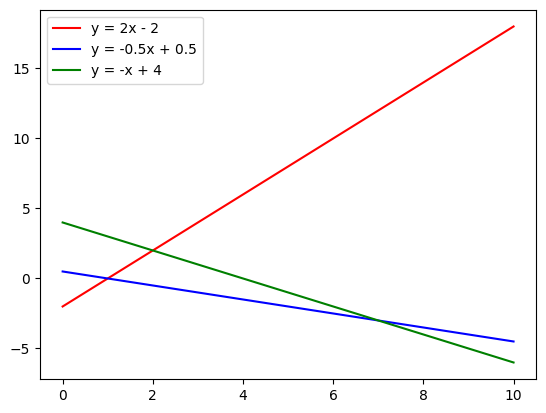

In [74]:
x = np.linspace(0, 10, 100)

plt.plot(x, 2 * x - 2, 'r', label = 'y = 2x - 2')
plt.plot(x, -0.5 * x + 0.5, 'b', label = 'y = -0.5x + 0.5')
plt.plot(x, -x + 4, 'g', label = 'y = -x + 4')

plt.legend()
plt.show()

Как мы видим, нет точки, в которой линии бы пересекались. Перепишем систему в
виде матрицы и вектора.

In [75]:
A = np.array([[2, -1],
              [1, 2],
              [1, 1]])

b = np.array([2, 1, 4])

Опять же решить систему методом Гаусса у нас не получится. То есть $ \mathbf A
\mathbf x = \mathbf b $ решения не имеет. Однако мы можем найти приближенное
решение через $ \mathbf A^\top \mathbf A \mathbf x^* = \mathbf A^\top \mathbf b $.
Найдем $\mathbf A^\top \mathbf A$ и $\mathbf A^\top \mathbf b$.


In [76]:
A_T_A = np.dot(A.T, A)
A_T_A

array([[6, 1],
       [1, 6]])

In [77]:
A_T_b = np.dot(A.T, b)
A_T_b

array([9, 4])

Таким образом, мы получили

$$ \begin{bmatrix} 6 & 1 \\ 1 & 6 \end{bmatrix} \mathbf x^* = \begin{bmatrix} 9 \\ 4
\end{bmatrix} $$

Решим систему (а такая система уже решается) методом Гаусса. Применим
следующие элементарные преобразования:
* $R_1 = \frac{R_1}{6};$
* $R_2=R_2-R_1;$
* $R_2=\frac{6R_2}{35};$
* $R_1=R_1-\frac{R_2}{6}.$

В результате получим следующую матрицу

$$ \begin{bmatrix} 1 & 0 & \frac{10}{7} \\ 0 & 1 & \frac{3}{7} \end{bmatrix} \approx
\begin{bmatrix} 1 & 0 & 1{,}43 \\ 0 & 1 & 0{,}43 \end{bmatrix} $$

Таким образом, вектор $ \begin{bmatrix} 1{,}43 \\ 0{,}43 \end{bmatrix} $ будет
решением этой системы уравнений.

Обозначим его на графике.

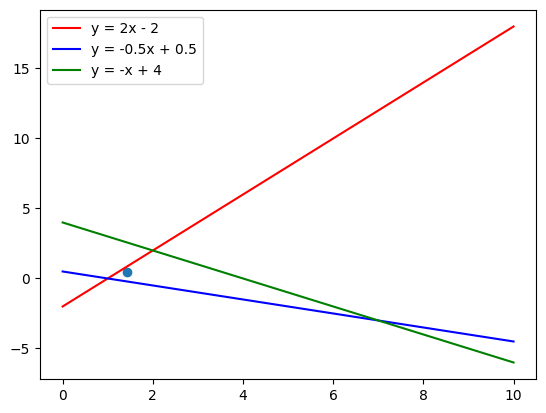

In [78]:
x = np.linspace(0, 10, 100)

plt.plot(x, 2 * x - 2, 'r', label = 'y = 2x - 2')
plt.plot(x, -0.5 * x + 0.5, 'b', label = 'y = -0.5x + 0.5')
plt.plot(x, -x + 4, 'g', label = 'y = -x + 4')

plt.scatter(1.43, 0.43)

plt.legend()
plt.show()

Решим эту задачу на Питоне. Вначале с помощью функции **np.linalg.lstsq()**.

In [79]:
np.linalg.lstsq(A, b, rcond = None)[0].round(2)

array([1.43, 0.43])

Теперь с помощью класса LinearRegression библиотеки sklearn (напомню, что этот
класс также использует метод наименьших квадратов).

In [80]:
from sklearn.linear_model import LinearRegression

LinearRegression(fit_intercept = False).fit(A, b).coef_.round(2)

array([1.43, 0.43])

Дополнительно проверим, получим ли мы такой же результат с помощью метода
градиентного спуска, а заодно убедимся, что метод наименьших квадратов
одновременно минимизирует расстояние от точек до прямой вдоль оси y.

In [81]:
class gd():
  def __init__(self):
    self.thetas = None
    self.loss_history = []

  def add_ones(self, x):
    return np.c_[np.ones((len(x), 1)), x]

  def objective(self, x, y, thetas, n):
    return np.sum((y - self.h(x, thetas)) ** 2) / (2 * n)

  def h(self, x, thetas):
    return np.dot(x, thetas)

  def gradient(self, x, y, thetas, n):
    return np.dot(-x.T, (y - self.h(x, thetas))) / n

  def fit(self, x, y, iter = 20000, learning_rate = 0.05):
    x, y = x.copy(), y.copy()
    self.add_ones(x)

    thetas, n = np.zeros(x.shape[1]), x.shape[0]

    loss_history = []

    for i in range(iter):
      loss_history.append(self.objective(x, y, thetas, n))
      grad = self.gradient(x, y, thetas, n)
      thetas -= learning_rate * grad

    self.thetas = thetas
    self.loss_history = loss_history

  def predict(self, x):
    x = x.copy()
    self.add_ones(x)
    return np.dot(x, self.thetas)

In [82]:
model = gd()
# для таких несложных данных должно хватить и ста итераций
model.fit(A, b, iter = 100, learning_rate = 0.05)

model.thetas.round(2)

array([1.43, 0.43])

## Обратимость матрицы $\mathbf A^\top \mathbf A$
Общее решение требует нахождения обратной матрицы $(\mathbf A^\top \mathbf A)^{-1}$.

$$ \mathbf x = (\mathbf A^\top \mathbf A)^{-1} \mathbf A^\top \mathbf b $$

Посмотрим, в каких случаях матрица $\mathbf A^\top \mathbf A$ обратима.

Такая матрица будет обратима, если столбцы $\mathbf A$ линейно независимы
(то есть матрица имеет полный ранг).

Приведем простой пример двух матриц $\mathbf A_1$ и $\mathbf A_2$
размерностью $3 \times 2$ с линейно независимыми (полный ранг) и линейно
зависимыми столбцами (ранг 1).

$$ \mathbf A_1 = \begin{bmatrix} 1 & 1 \\ 1 & 2 \\ 1 & 5 \end{bmatrix}, \hspace{5pt}
\mathbf A_2 = \begin{bmatrix} 1 & 3 \\ 1 & 3 \\ 1 & 3 \end{bmatrix} $$

Найдем $\mathbf A_1^\top \mathbf A_1$ и $\mathbf A_2^\top \mathbf A_2$.

$$ \mathbf A_1^\top \mathbf A_1 = \begin{bmatrix} 1 & 1 & 1 \\ 1 & 2 & 5
\end{bmatrix} \begin{bmatrix} 1 & 1 \\ 1 & 2 \\ 1 & 5 \end{bmatrix} = \begin{bmatrix}
3 & 8 \\ 8 & 30 \end{bmatrix} $$

$$ \mathbf A_2^\top \mathbf A_2 = \begin{bmatrix} 1 & 1 & 1 \\ 3 & 3 & 3
\end{bmatrix} \begin{bmatrix} 1 & 3 \\ 1 & 3 \\ 1 & 3 \end{bmatrix} = \begin{bmatrix}
3 & 9 \\ 9 & 27 \end{bmatrix} $$

Очевидно, в первом случае матрица обратима, во втором — нет. Приведем и более
формальное доказательство.

Предположим, что $\mathbf A^\top \mathbf A \mathbf x = \mathbf {0}.$ Тогда, чтобы
столбцы $\mathbf A^\top \mathbf A$ были линейно независимы, должно
выполняться условие, при котором ядро содержит только нулевой вектор
$null(\mathbf A) = \{ \mathbf 0 \}$ и $ \mathbf x = \mathbf {0} .$ Умножим обе части
на $ \mathbf x^\top.$

$$ \mathbf x^\top \mathbf A^\top \mathbf A \mathbf x = \mathbf x^\top \mathbf 0 $$

Получим умножение двух векторов (их результатом будет скаляр, а не нулевой вектор).

$$ (\mathbf A \mathbf x)^\top (\mathbf A \mathbf x) = 0 $$

$$ || \mathbf A \mathbf x ||^2 = 0 $$

Значит,

$$ \mathbf A \mathbf x = \mathbf 0 $$

Так как из $\mathbf A^\top \mathbf A \mathbf x = \mathbf 0$ следует, что $\mathbf A
\mathbf x = \mathbf {0},$ то можно сказать, что если $\mathbf x \in null(\mathbf
A^\top \mathbf A),$ то $\mathbf x \in null(\mathbf A).$ Отсюда

$$ null(\mathbf A^\top \mathbf A) = null(\mathbf A) $$

Из этого следует, что

$$ dim(null(\mathbf A^\top \mathbf A)) = dim(null(\mathbf A)) \implies rank(\mathbf
A^\top \mathbf A) = rank(\mathbf A) $$

В целом, как известно, матрица обратима, если она представляет собой квадратную
матрицу, и ее столбцы независимы (она имеет полный ранг). Мы знаем, что
$\mathbf A^\top \mathbf A$ квадратная и имеет тот же ранг, что и $\mathbf A.$
Соответственно, если $\mathbf A$ имеет полный ранг, то $\mathbf A^\top \mathbf A$
обратима.

Добавлю, что если матрицу $\mathbf A^\top \mathbf A$ возможно привести к
упрощенному ступенчатому виду (единичной матрице), т.е. $ rref(\mathbf A^\top
\mathbf A) = \mathbf I $, то она обратима.

### Про матрицу проекции
Выше мы сказали, что $ \mathbf p = \mathbf A \mathbf x^* .$ Одновременно, решив
нормальные уравнения получим $ \mathbf x^* = (\mathbf A^\top \mathbf A)^{-1}
\mathbf A^\top \mathbf {b} $ Как следствие,

$$ \mathbf p = \mathbf A \mathbf x^* = \mathbf A (\mathbf A^\top \mathbf A)^{-1}
\mathbf A^\top $$

#### Свойства матрицы проекции
Так мы получили матрицу проекции (projection matrix). Обозначим ее как $ \mathbf
P .$ Посмотрим на несколько интересных свойств. Во-первых, такая матрица
**симметрична**
$$ \mathbf P^\top = \mathbf P $$
Во-вторых, **квадрат матрицы** проекции равен самой матрице проекции $ \mathbf
P^2 = \mathbf P .$
$$ \mathbf A (\mathbf A^\top \mathbf A)^{-1} \cancel{\mathbf A^\top \mathbf A}
\cancel{(\mathbf A^\top \mathbf A)^{-1}} \mathbf A^\top = \mathbf A (\mathbf A^\top
\mathbf A)^{-1} \mathbf A^\top $$

Это же справедливо для любого количества степеней.

$\mathbf b \in col(\mathbf A)$

![](https://drive.google.com/uc?export=view&id=1XyrRFp5UuxKHphWcsihEQ01fw9jD2wuR)
$$\require{cancel}$$


Что интересно, если $\mathbf A \mathbf x = \mathbf b $ имеет решение, то есть
$\mathbf b \in col(\mathbf A),$ то $\mathbf A$ — будет квадратной обратимой матрицей, а значит, по свойству $(\mathbf A\mathbf B)^{-1} = \mathbf A^{-1}\mathbf
B^{-1},$

$$ \mathbf A\mathbf A^{-1} (\mathbf A^\top)^{-1} \mathbf A^\top = \mathbf I $$

Другими словами, если $\mathbf A \mathbf x = \mathbf b $ проецирует $\mathbf b$ на
$\mathbf A$ и $\mathbf b \in col(\mathbf A),$ то проекцией будет сам вектор $\mathbf
{b},$ а скалярной проекцией единица (единичная матрица).

$$ \mathbf P \mathbf b = \mathbf I \mathbf b = \mathbf b $$

Можно также сказать, что $ \mathbf A \mathbf x = \mathbf b, $

$$ \mathbf p = \mathbf P \mathbf b = (\mathbf A (\mathbf A^\top \mathbf A)^{-1}
\mathbf A^\top) \mathbf A \mathbf x = \mathbf A \cancel{(\mathbf A^\top \mathbf
A)^{-1}} \cancel{(\mathbf A^\top \mathbf A)} \mathbf x = \mathbf A \mathbf x $$

$\mathbf b \perp col(\mathbf A)$

![](https://drive.google.com/uc?export=view&id=1JJWxQB5W3wqiFRki6Y4-fh5XBV1VCFBw)

Если вектор $\mathbf b$ ортогонален пространству столбцов $col(\mathbf A),$ то он
находится в ядре $\mathbf A^\top.$ Логично, что проекция $\mathbf b$ на
$col(\mathbf A)$ представляет собой нулевой вектор.

$$ \mathbf P \mathbf b = \mathbf 0 $$

### Метод максимального правдоподобия
Рассмотрим модель простой линейной регрессии с независимыми одинаково
распределенными наблюдениями.

$$ y_i = \theta_0 + \theta_1 x_i + \varepsilon_i, \; \varepsilon_i \sim \mathcal{N}(0,
\sigma^2), \; i = 1,\ldots,n $$

Проиллюстрируем эту модель для трех наблюдений $x_1, x_2, x_3.$

![](https://drive.google.com/uc?export=view&id=10mbGBc2nhu9GINrib0VD3YVee1LSyHg3)

Применим **метод максимального правдоподобия** (maximum likelihood
estimation) для оценки параметров $\theta_0, \theta_1$ и $\sigma^2.$

$$ \begin{split} P(y \mid \theta_0, \theta_1,\sigma^2) &= \prod_{i=1}^n P(y_i \mid
\theta_0,\theta_1,\sigma^2) \\ &= \prod_{i=1}^n \mathcal{N}(y_i; \theta_0 + \theta_1
x_i, \sigma^2) \\ &= \prod_{i=1}^n \frac{1}{\sqrt{2 \pi \sigma}} \cdot \exp \left[ -
\frac{(y_i-\theta_0-\theta_1 x_i)^2}{2 \sigma^2} \right] \\ &= \frac{1}{\sqrt{(2 \pi
\sigma^2)^n}} \cdot \exp\left[ -\frac{1}{2 \sigma^2} \sum_{i=1}^n (y_i-\theta_0-
\theta_1 x_i)^2 \right] \end{split} $$

Возьмем логарифм от функции правдоподобия.

$$ \begin{split} \ell(\theta_0,\theta_1,\sigma^2) &= \log P(y \mid
\theta_0,\theta_1,\sigma^2) \\ &= -\frac{n}{2} \log(2\pi)-\frac{n}{2} \log (\sigma^2) -
\frac{1}{2 \sigma^2} \sum_{i=1}^n (y_i-\theta_0 — \theta_1 x_i)^2 \end{split} $$

Найдем производную $\ell$ относительно $\theta_0.$

$$ \frac{\mathrm{d} \ell (\theta_0,\theta_1,\sigma^2)}{\mathrm{d}\theta_0} = \frac{1}
{\sigma^2} \sum_{i=1}^n (y_i-\theta_0-\theta_1 x_i) $$

Приравняем к нулю и выразим $\theta_0.$

$$ \begin{split} \frac{\mathrm{d} \ell (\hat{\theta}_0,\hat{\theta}_1,\hat{\sigma}^2)}
{\mathrm{d}\theta_0} &= 0 \\ 0 &= \frac{1}{\hat{\sigma}^2} \sum_{i=1}^n (y_i-
\hat{\theta}_0-\hat{\theta}_1 x_i) \\ 0 &= \sum_{i=1}^n y_i-n \hat{\theta}_0-
\hat{\theta}_1 \sum_{i=1}^n x_i \ \hat{\theta}_0 &= \frac{1}{n} \sum_{i=1}^n y_i-
\hat{\theta}_1 \frac{1}{n} \sum_{i=1}^n x_i \\ \hat{\theta}_0 &= \bar{y}-\hat{\theta}_1
\bar{x} \end{split} $$

Найдем производную $\ell$ со значением $\hat{\theta}_0$ относительно $\theta_1.$

$$ \frac{\mathrm{d} \ell (\hat{\theta}_0,\theta_1,\sigma^2)}{\mathrm{d}\theta_1} =
\frac{1}{\sigma^2} \sum_{i=1}^n (x_i y_i-\hat{\theta}_0 x_i-\theta_1 x_i^2) $$

Приравняем к нулю и выразим $\theta_1.$

$$ \begin{split} \frac{\mathrm{d} \ell (\hat{\theta}_0,\hat{\theta}_1,\hat{\sigma}^2)}
{\mathrm{d}\theta_1} &= 0 \\ 0 &= \frac{1}{\hat{\sigma}^2} \sum_{i=1}^n (x_i y_i-
\hat{\theta}_0 x_i-\hat{\theta}_1 x_i^2) \\ 0 &= \sum_{i=1}^n x_i y_i-\hat{\theta}_0
\sum_{i=1}^n x_i-\hat{\theta}_1 \sum_{i=1}^n x_i^2) \\ 0 &= \sum_{i=1}^n x_i y_i-
(\bar{y}-\hat{\theta}_1 \bar{x}) \sum_{i=1}^n x_i-\hat{\theta}_1 \sum_{i=1}^n x_i^2 \\
0 &= \sum_{i=1}^n x_i y_i-\bar{y} \sum_{i=1}^n x_i + \hat{\theta}_1 \bar{x}
\sum_{i=1}^n x_i-\hat{\theta}_1 \sum_{i=1}^n x_i^2 \\ 0 &= \sum_{i=1}^n x_i y_i-n
\bar{x} \bar{y} + \hat{\theta}_1 n \bar{x}^2-\hat{\theta}_1 \sum_{i=1}^n x_i^2 \\
\hat{\theta}_1 &= \frac{\sum_{i=1}^n x_i y_i-\sum_{i=1}^n \bar{x} \bar{y}}
{\sum_{i=1}^n x_i^2-\sum_{i=1}^n \bar{x}^2} \\ \hat{\theta}_1 &= \frac{\sum_{i=1}^n
(x_i-\bar{x}) (y_i-\bar{y})}{\sum_{i=1}^n (x_i-\bar{x})^2} \end{split} $$

Как мы видим, метод максимального правдоподобия дал тот же результат, что и
аналитический метод.

Осталось получить MLE-оценку $\sigma^2.$ Найдем производную $\ell$ со
значением $(\hat{\theta}_0, \hat{\theta}_1)$ относительно $\theta_1.$

$$ \frac{\mathrm{d} \ell (\hat{\theta}_0,\hat{\theta}_1,\sigma^2)}
{\mathrm{d}\sigma^2} = -\frac{n}{2\sigma^2} + \frac{1}{2(\sigma^2)^2}
\sum_{i=1}^n (y_i-\hat{\theta}_0-\hat{\theta}_1 x_i)^2 $$

Приравняем производную к нулю и выразим $\sigma^2.$

$$ \begin{split} \frac{\mathrm{d} \ell (\hat{\theta}_0,\hat{\theta}_1,\hat{\sigma}^2)}
{\mathrm{d}\sigma^2} &= 0 \\ 0 &= -\frac{n}{2\hat{\sigma}^2} + \frac{1}
{2(\hat{\sigma}^2)^2} \sum_{i=1}^n (y_i-\hat{\theta}_0-\hat{\theta}_1 x_i)^2 \\
\frac{n}{2\hat{\sigma}^2} &= \frac{1}{2(\hat{\sigma}^2)^2} \sum_{i=1}^n (y_i-
\hat{\theta}_0-\hat{\theta}_1 x_i)^2 \\ \hat{\sigma}^2 &= \frac{1}{n} \sum_{i=1}^n
(y_i-\hat{\theta}_0-\hat{\theta}_1 x_i)^2 \end{split} $$

Теперь рассмотрим модель множественной линейной регрессии с независимыми
одинаково распределенными наблюдениями

$$ \mathbf y = \mathbf X \boldsymbol \theta + \varepsilon, \varepsilon \sim \mathcal{N}
(0, \sigma^2 \mathbf I), $$

где остатки следуют многомерному нормальному распределению с нулевым
средним и дисперсией, равной $\sigma^2 \mathbf I.$

$$ \begin{split} P(\mathbf y \mid \boldsymbol \theta, \sigma^2) &= \mathcal{N}(\mathbf
y; \mathbf X \boldsymbol \theta, \sigma^2 \mathbf I) \\ &= \sqrt{\frac{1}{(2\pi)^n
|\sigma^2 \mathbf I|}} \cdot \exp\left[ -\frac{1}{2} (\mathbf y-\mathbf X \boldsymbol
\theta)^\top (\sigma^2 \mathbf I)^{-1} (\mathbf y-\mathbf X \boldsymbol \theta) \right]
\end{split} $$

Используя свойство умножения определителя матрицы на скаляр $| \sigma^2
\mathbf I | = (\sigma^2)^n |\mathbf I|, $ зададим логарифмическую функцию правдоподобия.

$$ \begin{split} \ell (\boldsymbol \theta,\sigma^2) =& \; \log P(\mathbf y \mid
\boldsymbol \theta, \sigma^2) \\ =& -\frac{n}{2} \log(2\pi)-\frac{n}{2} \log (\sigma^2)-
\frac{1}{2} \log (|\mathbf I|) \\ & -\frac{1}{2 \sigma^2} (\mathbf y-\mathbf X
\boldsymbol \theta)^\top \mathbf I^{-1} (\mathbf y-\mathbf X \boldsymbol \theta) \\ =& -
\frac{n}{2} \log(2\pi)-\frac{n}{2} \log(\sigma^2)-\frac{1}{2} \log(|\mathbf I|) \\ & -
\frac{1}{2 \sigma^2} \left(\mathbf y^\top \mathbf I^{-1} \mathbf y-2 \boldsymbol
\theta^\top \mathbf X^\top \mathbf I^{-1} \mathbf y + \boldsymbol \theta^\top \mathbf
X^\top \mathbf I^{-1} \mathbf X \boldsymbol \theta \right) \end{split} $$

Найдем производную $\ell$ относительно $\boldsymbol \theta.$

$$ \begin{split} \frac{ \partial \ell (\boldsymbol \theta, \sigma^2) }{ \partial \boldsymbol
\theta } &= \frac{\partial}{\partial \boldsymbol \theta} \left( -\frac{1}{2 \sigma^2} \left(
\mathbf y^\top \mathbf I^{-1} \mathbf y-2 \boldsymbol \theta^\top \mathbf X^\top
\mathbf I^{-1} \mathbf y + \boldsymbol \theta^\top \mathbf X^\top \mathbf I^{-1}
\mathbf X \boldsymbol \theta\right) \right) \\ &= \frac{1}{2 \sigma^2} \frac{\partial}
{\partial \boldsymbol \theta} \left( 2 \boldsymbol \theta^\top \mathbf X^\top \mathbf
I^{-1} \mathbf y-\boldsymbol \theta^\top \mathbf X^\top \mathbf I^{-1} \mathbf X
\boldsymbol \theta \right) \\ &= \frac{1}{2 \sigma^2} \left( 2 \mathbf X^\top \mathbf
I^{-1} \mathbf y-2 \mathbf X^\top \mathbf I^{-1} \mathbf X \boldsymbol \theta \right) \\
&= \frac{1}{\sigma^2} \left( \mathbf X^\top \mathbf I^{-1} \mathbf y-\mathbf X^\top
\mathbf I^{-1} \mathbf X \boldsymbol \theta \right) \end{split} $$

Приравняем производную к нулю и выразим $\boldsymbol \theta.$

$$ \begin{split} \frac{\partial \ell (\hat{\boldsymbol \theta},\sigma^2)}{\partial
\boldsymbol \theta} &= 0 \\ 0 &= \frac{1}{\sigma^2} \left( \mathbf X^\top \mathbf
I^{-1} \mathbf y-\mathbf X^\top \mathbf I^{-1} \mathbf X \hat{\boldsymbol \theta}
\right) \\ 0 &= \mathbf X^\top \mathbf I^{-1} \mathbf y-\mathbf X^\top \mathbf I^{-1}
\mathbf X \hat{\boldsymbol \theta} \\ \mathbf X^\top \mathbf I^{-1} \mathbf X
\hat{\boldsymbol \theta} &= \mathbf X^\top \mathbf I^{-1} \mathbf y \\
\hat{\boldsymbol \theta} &= \left( \mathbf X^\top \mathbf I^{-1} \mathbf X \right)^{-1}
\mathbf X^\top \mathbf I^{-1} \mathbf y \\ \hat{\boldsymbol \theta} &= \left( \mathbf
X^\top \mathbf X \right)^{-1} \mathbf X^\top \mathbf y \end{split} $$

Найдем производную функции $\ell$ со значением $\hat{\boldsymbol \theta}$
относительно $\sigma^2.$

$$ \begin{split} \frac{\partial \ell (\hat{\boldsymbol \theta},\sigma^2)}{\partial
\sigma^2} &= \frac{\partial}{\partial \sigma^2} \left( -\frac{n}{2} \log (\sigma^2)-
\frac{1}{2 \sigma^2} (\mathbf y-\mathbf X\hat{\boldsymbol \theta})^\top \mathbf I^{-1}
(\mathbf y-\mathbf X\hat{\boldsymbol \theta}) \right) \\ &= -\frac{n}{2} \frac{1}
{\sigma^2} + \frac{1}{2 (\sigma^2)^2} (\mathbf y-\mathbf X\hat{\boldsymbol
\theta})^\top \mathbf I^{-1} (\mathbf y-\mathbf X\hat{\boldsymbol \theta}) \\ &= —
\frac{n}{2 \sigma^2} + \frac{1}{2 (\sigma^2)^2} (\mathbf y-\mathbf X\hat{\boldsymbol
\theta})^\top \mathbf I^{-1} (\mathbf y-\mathbf X\hat{\boldsymbol \theta}) \end{split}
$$

Приравняем производную к нулю и выразим $\sigma^2.$

$$ \begin{split} \frac{\partial \ell (\hat{\boldsymbol \theta},\hat{\sigma}^2)}{\partial
\sigma^2} &= 0 \\ 0 &= -\frac{n}{2 \hat{\sigma}^2} + \frac{1}{2 (\hat{\sigma}^2)^2}
(\mathbf y-\mathbf X\hat{\boldsymbol \theta})^\top \mathbf I^{-1} (\mathbf y-\mathbf
X\hat{\boldsymbol \theta}) \\ \frac{n}{2 \hat{\sigma}^2} &= \frac{1}{2
(\hat{\sigma}^2)^2} (\mathbf y-\mathbf X\hat{\boldsymbol \theta})^\top \mathbf I^{-1}
(y-X\hat{\boldsymbol \theta}) \\ \frac{2 (\hat{\sigma}^2)^2}{n} \cdot \frac{n}{2
\hat{\sigma}^2} &= \frac{2 (\hat{\sigma}^2)^2}{n} \cdot \frac{1}{2
(\hat{\sigma}^2)^2} (\mathbf y-\mathbf X\hat{\boldsymbol \theta})^\top \mathbf I^{-1}
(\mathbf y-\mathbf X\hat{\boldsymbol \theta}) \\ \hat{\sigma}^2 &= \frac{1}{n}
(\mathbf y-\mathbf X\hat{\boldsymbol \theta})^\top \mathbf I^{-1} (\mathbf y-\mathbf
X\hat{\boldsymbol \theta}) \\ \hat{\sigma}^2 &= \frac{1}{n} (\mathbf y-\mathbf
X\hat{\boldsymbol \theta})^\top (\mathbf y-\mathbf X\hat{\boldsymbol \theta})
\end{split} $$

## Масштабирование признаков
Рассмотрим линейную регрессию с двумя независимыми переменными с разным
масштабом. Например, пусть один признак находится в диапазоне от 0 до 1000, а
второй — от 0 до 1. Для того чтобы настроиться на такие признаки, модель выберет
небольшой первый и большой второй коэффициенты.


Проблема подобной модели в том, что на этапе обучения скорость оптимизации таких коэффициентов (весов, параметров) не будет одинаковой.


На графике изолиний (как бы «вид сверху») функция потерь такой модели примет
эллиптическую форму (по оси x соответственно будет отложен признак с
небольшим диапазоном, по оси y — с большим).

In [83]:
def paraboloid_countours(min, max, a = 1, b = 1, w1_list = None, w2_list = None):

  # установим размер графика
  fig, ax = plt.subplots(figsize = (10,10))

  # создадим последовательность из 100 точек в интервале от -10 до 10
  # для осей w1 и w2
  w1_plot = np.arange(min, max, 0.02)
  w2_plot = np.arange(min, max, 0.02)

  # создадим координатную плоскость из осей w1 и w2
  w1_plot, w2_plot = np.meshgrid(w1_plot, w2_plot)

  f = (w1_plot ** 2)/a + (w2_plot ** 2)/b

  # построим изолинии (линии уровня)
  ax.contourf(w1_plot, w2_plot, f, cmap = 'Blues')

  # если функции передали списки весов, выведем траекторию их обновления
  if w1_list != None and w2_list != None:
    ax.plot(w1_list, w2_list, c = 'red')

  # укажем подписи к осям
  ax.set_xlabel('w1', fontsize = 15)
  ax.set_ylabel('w2', fontsize = 15)

  # создадим сетку в виде прерывистой черты
  plt.grid(linestyle = '--')

  # выведем результат
  plt.show()

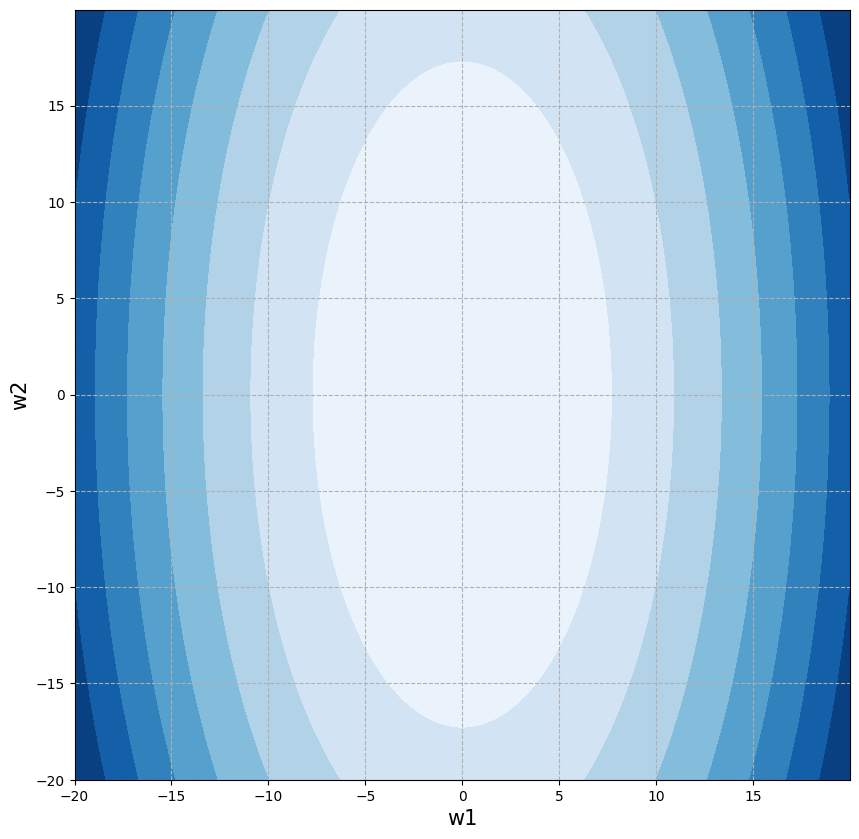

In [84]:
paraboloid_countours(-20, 20, 1, 5)

При использовании алгоритма градиентного спуска мы в первую очередь найдем
две частные производные этой функции и подберем *единый* для обеих
производных коэффициент скорости обучения. Так как масштаб признаков будет
различным, на каждой итерации мы будем получать существенно различающиеся
значения градиента для разных направлений.

Пропишем функцию потерь и найдем ее частные производные.

Признаки с разным масштабом

In [85]:
# пропишем функцию потерь
# (переменные a и b будут определять масштаб каждого из признаков)
def objective(w1, w2, a, b):
    return (w1 ** 2) / a + (w2 ** 2) / b

# производную по первой
def partial_1(w1, a):
  return (2.0 * w1) / a

# и второй переменным
def partial_2(w2, b):
  return (2.0 * w2) / b

Попробуем найти оптимальные веса с помощью алгоритма градиентного спуска.

In [86]:
def paraboloid_gd(w1, w2, a, b, iter = 100, learning_rate = 0.025):

  # создадим списки для учета весов и уровня ошибки
  w1_list, w2_list, l_list = [], [], []

  # в цикле с заданным количеством итераций
  for i in range(iter):

    # будем добавлять текущие веса в соответствующие списки
    w1_list.append(w1)
    w2_list.append(w2)

    # и рассчитывать и добавлять в список текущий уровень ошибки
    l_list.append(objective(w1, w2, a, b))

    # также рассчитаем значение частных производных при текущих весах
    par_1 = partial_1(w1, a)
    par_2 = partial_2(w2, b)

    # будем обновлять веса в направлении,
    # обратном направлению градиента, умноженному на скорость обучения
    w1 = w1 - learning_rate * par_1
    w2 = w2 - learning_rate * par_2

  # выведем итоговые веса модели и значение функции потерь
  return w1_list, w2_list, l_list

In [87]:
w1_list, w2_list, l_list = paraboloid_gd(15, 15, 1, 5)
w1_list[-1], w2_list[-1], l_list[-1]

(0.09348204032106357, 5.545944564745904, 6.1602391149095155)

Вновь выведем изолинии функции потерь, дополнив их траекторией изменения
весов признаков.

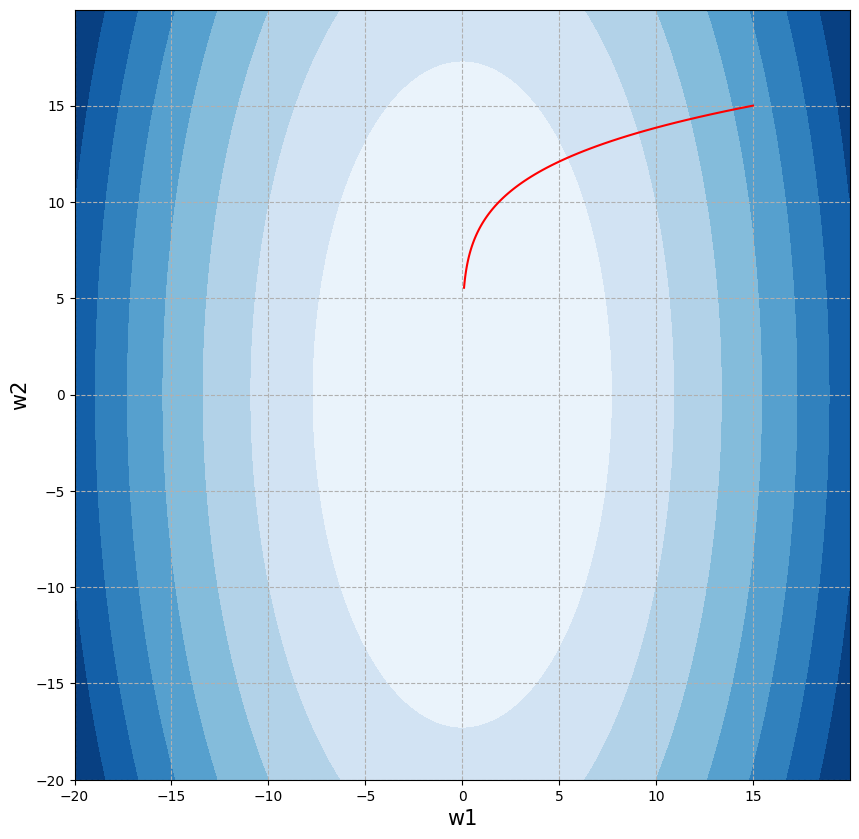

In [88]:
paraboloid_countours(-20, 20, 1, 5, w1_list, w2_list)

Мы не смогли дойти до минимума. Для иллюстрации этой особенности можно
также вывести графики изменения весов в процессе обучения алгоритма.

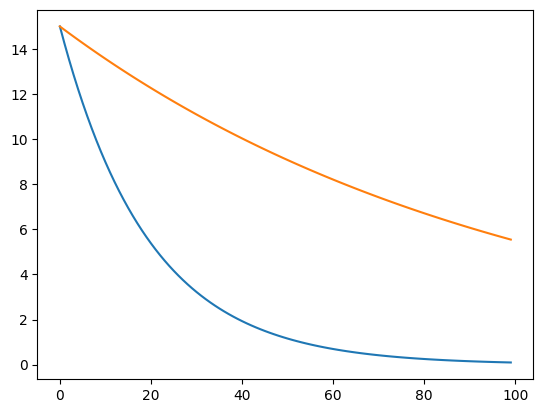

In [89]:
plt.plot(w1_list)
plt.plot(w2_list)
plt.show()

Посмотрим, что будет, если привести признаки к одному масштабу. Вначале
найдем минимум методом градиентного спуска.

Признаки после масштабирования

In [90]:
# напомню, параметры a и b в данном случае контролируют масштаб признаков
w1_list, w2_list, l_list = paraboloid_gd(15, 15, 1, 1)
w1_list[-1], w2_list[-1], l_list[-1]

(0.09348204032106357, 0.09348204032106357, 0.017477783725177908)

Выведем результат на графике.

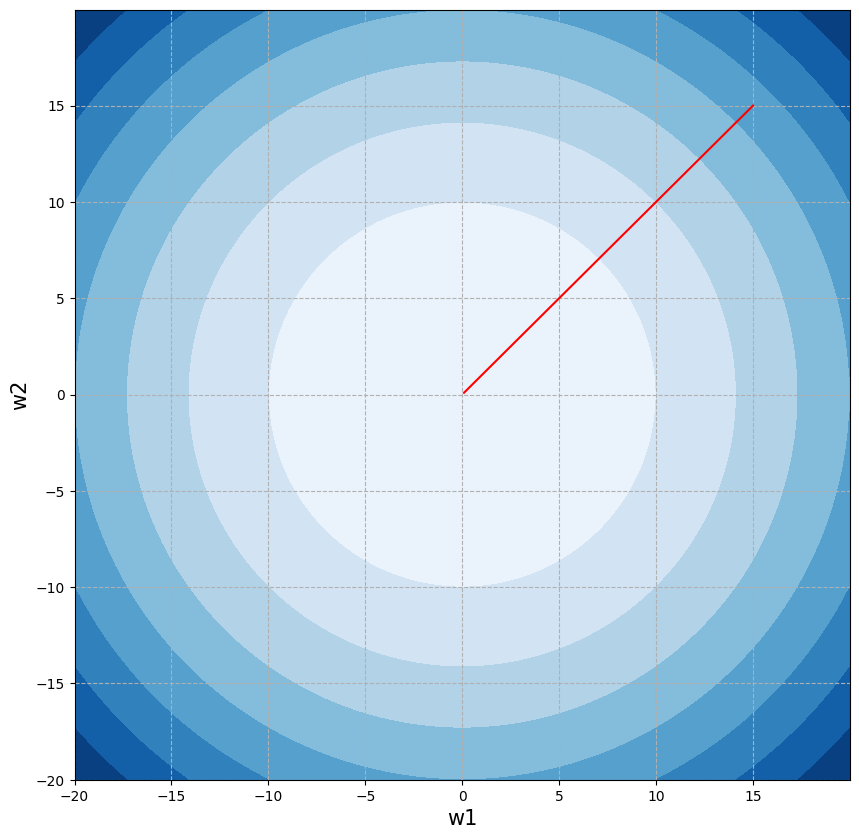

In [91]:
paraboloid_countours(-20, 20, 1, 1, w1_list, w2_list)

Посмотрим на обновления весов.

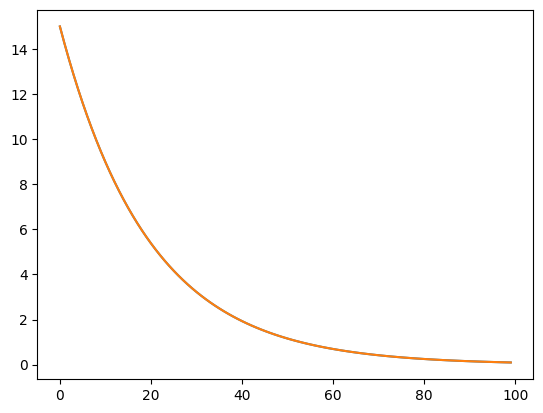

In [92]:
plt.plot(w1_list)
plt.plot(w2_list)
plt.show()

Мы видим только оранжевую линию, потому что одна кривая перекрывает другую.

## Полиномиальная регрессия

Данные далеко не всегда хорошо аппроксимируются прямой линией. Создадим
искусственный набор данных.

In [93]:
np.random.seed(42)
X = np.random.normal(2, 4, 50)
y = 2 * X ** 2 + 2 * X + 50 + np.random.normal(3, 10, 50)

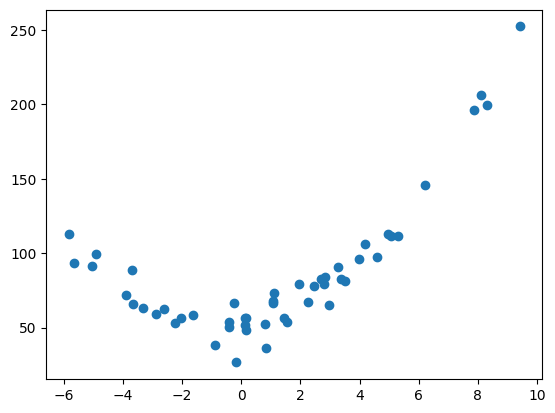

In [94]:
plt.scatter(X, y);

Попробуем «наложить» на данные модель линейной регрессии.

In [95]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X.reshape(-1, 1), y)
y_pred = model.predict(X.reshape(-1, 1))

Посмотрим на получившиеся коэффициенты.

In [96]:
model.coef_, model.intercept_

(array([7.65521764]), np.float64(76.7171405919949))

Выведем результат на графике и оценим качество через RMSE и $R^2$.

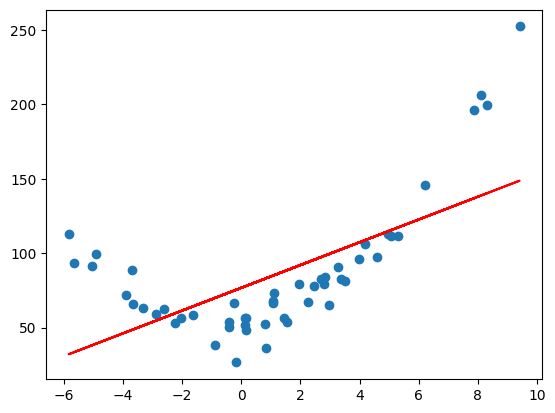

In [97]:
plt.scatter(X, y)
plt.plot(X, y_pred, color='r')
plt.show()

In [98]:
from sklearn.metrics import root_mean_squared_error, r2_score

root_mean_squared_error(y, y_pred), r2_score(y, y_pred)

(34.5483663960937, 0.40159428156318455)

В данном случае очевидно, что данные гораздо более удачно моделировать с
помощью квадратичной функции (quadratic function).

$$ \hat{y} = \theta_0 + \theta_1x + \theta_2x^2 $$

Обратите внимание, что в квадрат возводится не коэффициент $\theta$, а признак
$x$. Поэтому все, что нам нужно, это создать еще один признак, равный квадрату
исходного признака. Для этого в sklearn есть **класс PolynomialFeatures**.

In [99]:
from sklearn.preprocessing import PolynomialFeatures

polynomial_features = PolynomialFeatures(degree = 2, include_bias = False)
X_poly = polynomial_features.fit_transform(X.reshape(-1, 1))

Параметр include_bias регулирует, добавлять ли столбец из единиц для свободного
коэффициента или нет. Так как в данном случае мы используем класс
LinearRegression, который сам рассчитывает все коэффициенты, такой столбец нам
не понадобится.

In [100]:
# сравним исходный признак
X[:5]

array([3.98685661, 1.4469428 , 4.59075415, 8.09211943, 1.0633865 ])

In [101]:
# с новыми
X_poly[:5]

array([[ 3.98685661, 15.89502565],
       [ 1.4469428 ,  2.09364345],
       [ 4.59075415, 21.07502369],
       [ 8.09211943, 65.4823968 ],
       [ 1.0633865 ,  1.13079085]])

Второй столбец — квадрат первого.

In [102]:
3.98685661 ** 2

15.89502562870069

In [103]:
X.shape, X_poly.shape

((50,), (50, 2))

Построим модель.

In [104]:
model = LinearRegression()

model.fit(X_poly, y)
y_poly_pred = model.predict(X_poly)

model.coef_, model.intercept_

(array([2.31100218, 1.98024538]), np.float64(53.13013943148053))

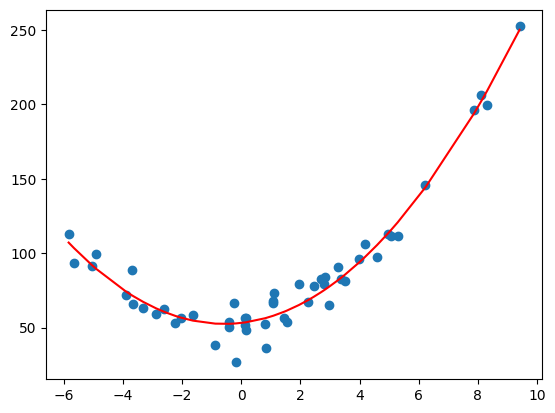

In [105]:
import operator

sort_axis = operator.itemgetter(0)
sorted_zip = sorted(zip(X, y_poly_pred), key = sort_axis)
X_plot, y_poly_pred_plot = zip(*sorted_zip)

plt.plot(X_plot, y_poly_pred_plot, color = 'r')
plt.scatter(X, y)

plt.show()

In [106]:
root_mean_squared_error(y, y_poly_pred), r2_score(y, y_poly_pred)

(8.596303829633031, 0.9629520471499875)

Два важных замечания:
* масштабирование признаков становится особенно значимым при оптимизации
полиномиальных коэффициентов методом градиентного спуска (потому что,
например, если мы возводим признак в квадрат, его диапазон также
увеличивается аналогичным образом);
* функция не обязательно должна быть степенной; если нам нужно предсказать
данные, которые растут, но затем выходят на плато (например, цены), можно
использовать, в частности, фунцию квадратного корня.